# NBA Injury Risk — ML Modeling: NBA Injury Risk Prediction
## game_logs_features Dataset

# 1. Import and Setup


In [1]:
# Standard library
import os
import warnings
from pathlib import Path

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model selection and evaluation
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report,
)

# Class imbalance
from imblearn.over_sampling import SMOTE

# Persistence
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
import sklearn, xgboost, imblearn
print(f"sklearn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"imblearn: {imblearn.__version__}")


Libraries loaded.
pandas:  3.0.2
numpy:   2.4.4
sklearn: 1.8.0
xgboost: 3.2.0
imblearn: 0.14.1


# 2. Load Data

In [2]:
DATA_DIR = Path("../data/processed")
ARTIFACTS_DIR = Path("../models")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "game_logs_features.csv", parse_dates=["GAME_DATE"])

print(f"Shape: {df.shape}")
print(f"Date range: {df['GAME_DATE'].min().date()} to {df['GAME_DATE'].max().date()}")
print(f"Seasons: {sorted(df['SEASON_YEAR'].unique())}")
print(f"Unique players: {df['PLAYER_ID'].nunique():,}")
print(f"\nOverall injury rate: {df['injury_within_30_days'].mean():.1%}")

Shape: (216088, 56)
Date range: 2015-10-27 to 2023-06-12
Seasons: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Unique players: 1,248

Overall injury rate: 18.1%


In [3]:
# Null counts on columns we care about — the 22 features + target
feature_cols = [
    "age",
    "rest_days",
    "is_back_to_back",
    "rolling_7d_min",
    "rolling_14d_min",
    "rolling_28d_min",
    "games_last_7d",
    "rolling_5game_min",
    "cumulative_season_min",
    "acwr",
    "acwr_danger_zone",
    "prior_injury_count",
    "recent_hamstring_injury",
    "recent_quadriceps_injury",
    "recent_calf_injury",
    "recent_groin_injury",
    "recent_ankle_injury",
    "recent_achilles_injury",
    "recent_knee_injury",
    "recent_back_injury",
    "recent_hip_injury",
    "recent_foot_injury",
]
target_col = "injury_within_30_days"

null_report = df[feature_cols].isna().sum().to_frame("null_count")
null_report["null_pct"] = (null_report["null_count"] / len(df) * 100).round(2)
null_report = null_report.sort_values("null_count", ascending=False)
print("Nulls in feature columns (before imputation):")
print(null_report[null_report["null_count"] > 0])

Nulls in feature columns (before imputation):
                       null_count  null_pct
acwr                        51576     23.87
rolling_7d_min              15076      6.98
games_last_7d               15076      6.98
rolling_14d_min              7791      3.61
rolling_28d_min              5687      2.63
cumulative_season_min        4252      1.97
rolling_5game_min            1248      0.58
rest_days                    1248      0.58


# 3. Chronological Train / Validation / Test Split

In [4]:
TRAIN_SEASONS = ["2015-16", "2016-17", "2017-18", "2018-19", "2019-20", "2020-21"]
VAL_SEASONS = ["2021-22"]
TEST_SEASONS = ["2022-23"]

train_df = df[df["SEASON_YEAR"].isin(TRAIN_SEASONS)].copy()
val_df = df[df["SEASON_YEAR"].isin(VAL_SEASONS)].copy()
test_df = df[df["SEASON_YEAR"].isin(TEST_SEASONS)].copy()

# Sanity check — no overlap, every row accounted for
assert len(train_df) + len(val_df) + len(test_df) == len(df), "Split does not cover all rows"

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "seasons": [", ".join(TRAIN_SEASONS), ", ".join(VAL_SEASONS), ", ".join(TEST_SEASONS)],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "positive_count": [
        int(train_df[target_col].sum()),
        int(val_df[target_col].sum()),
        int(test_df[target_col].sum()),
    ],
    "positive_pct": [
        f"{train_df[target_col].mean():.1%}",
        f"{val_df[target_col].mean():.1%}",
        f"{test_df[target_col].mean():.1%}",
    ],
})
print(split_summary.to_string(index=False))

split                                              seasons   rows  positive_count positive_pct
train 2015-16, 2016-17, 2017-18, 2018-19, 2019-20, 2020-21 160541           26808        16.7%
  val                                              2021-22  27927            6504        23.3%
 test                                              2022-23  27620            5760        20.9%


In [5]:
# Injury rate trend per season — context for interpreting drift
season_rate = df.groupby("SEASON_YEAR")[target_col].agg(["count", "sum", "mean"])
season_rate.columns = ["games", "injuries", "injury_rate"]
season_rate["injury_rate_pct"] = (season_rate["injury_rate"] * 100).round(1)
print("Injury rate by season:")
print(season_rate[["games", "injuries", "injury_rate_pct"]])
print("\nThe upward trend (11.8% -> 23.3%) means class balance is NOT stable.")
print("Validation (2021-22) has a higher positive rate than most of training —")
print("expect this to affect raw PR-AUC comparisons across years.")

Injury rate by season:
             games  injuries  injury_rate_pct
SEASON_YEAR                                  
2015-16      27973      3301             11.8
2016-17      27874      4125             14.8
2017-18      27833      5062             18.2
2018-19      27859      5174             18.6
2019-20      24084      4306             17.9
2020-21      24918      4840             19.4
2021-22      27927      6504             23.3
2022-23      27620      5760             20.9

The upward trend (11.8% -> 23.3%) means class balance is NOT stable.
Validation (2021-22) has a higher positive rate than most of training —
expect this to affect raw PR-AUC comparisons across years.


# 4. Feature Matrix and Target

In [6]:
# Columns to drop from features — identifiers, box score stats, and is_playoff
drop_cols = [
    # Identifiers
    "SEASON_YEAR", "PLAYER_ID", "PLAYER_NAME", "TEAM_ID", "TEAM_ABBREVIATION",
    "TEAM_NAME", "GAME_ID", "GAME_DATE", "MATCHUP", "WL",
    # Raw box score stats — game outcomes, not workload inputs
    "MIN", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT", "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB", "AST", "TOV", "STL", "BLK", "BLKA", "PF", "PFD",
    "PTS", "PLUS_MINUS",
    # Excluded from features
    "is_playoff",
]

# Sanity check: feature_cols + drop_cols + target_col should cover all 56 columns
expected = set(feature_cols) | set(drop_cols) | {target_col}
actual = set(df.columns)
missing = actual - expected
extra = expected - actual
assert not missing, f"Columns not accounted for: {missing}"
assert not extra, f"Expected columns not found: {extra}"

print(f"Feature count: {len(feature_cols)}")
print(f"Dropped columns: {len(drop_cols)}")
print(f"Target: {target_col}")

# Build X, y per split
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print(f"\nX_train: {X_train.shape}, y_train positives: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"X_val:   {X_val.shape}, y_val positives:   {y_val.sum():,} ({y_val.mean():.1%})")
print(f"X_test:  {X_test.shape}, y_test positives:  {y_test.sum():,} ({y_test.mean():.1%})")

Feature count: 22
Dropped columns: 33
Target: injury_within_30_days

X_train: (160541, 22), y_train positives: 26,808 (16.7%)
X_val:   (27927, 22), y_val positives:   6,504 (23.3%)
X_test:  (27620, 22), y_test positives:  5,760 (20.9%)


# 5. Missing Values

In [7]:
print("Nulls BEFORE imputation (train):")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

imputer = SimpleImputer(strategy="constant", fill_value=0)
imputer.fit(X_train)

# Transform and wrap back into a DataFrame so column names survive
X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=feature_cols, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=feature_cols, index=X_val.index)
# NOTE: X_test intentionally NOT imputed yet — deferred to final prep in section 13.

print("\nNulls AFTER imputation (train):")
print(X_train_imp.isna().sum().sum(), "total nulls")
print("Nulls AFTER imputation (val):")
print(X_val_imp.isna().sum().sum(), "total nulls")

Nulls BEFORE imputation (train):
rest_days                 1036
rolling_7d_min           10656
rolling_14d_min           5627
rolling_28d_min           4209
games_last_7d            10656
rolling_5game_min         1036
cumulative_season_min     3105
acwr                     37708
dtype: int64

Nulls AFTER imputation (train):
0 total nulls
Nulls AFTER imputation (val):
0 total nulls


# 6. Feature Scaling (Logistic Regression Only)

In [8]:
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_imp), columns=feature_cols, index=X_train_imp.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), columns=feature_cols, index=X_val_imp.index)

print("X_train_scaled mean (should be ~0):", X_train_scaled.mean().abs().max().round(6))
print("X_train_scaled std  (should be ~1):", X_train_scaled.std().round(4).describe()[["min", "max"]].to_dict())
print("\nReminder:")
print("  Logistic Regression -> X_train_scaled, X_val_scaled")
print("  Decision Tree / Random Forest -> X_train_imp, X_val_imp")
print("  XGBoost -> X_train (raw, NaNs preserved), X_val (raw, NaNs preserved)")

X_train_scaled mean (should be ~0): 0.0
X_train_scaled std  (should be ~1): {'min': 1.0, 'max': 1.0}

Reminder:
  Logistic Regression -> X_train_scaled, X_val_scaled
  Decision Tree / Random Forest -> X_train_imp, X_val_imp
  XGBoost -> X_train (raw, NaNs preserved), X_val (raw, NaNs preserved)


# 7. Class Imbalance — Option A: Class Weights

In [9]:
# scale_pos_weight for XGBoost: ratio of negatives to positives in training set
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count
print(f"Training set: {neg_count:,} negatives, {pos_count:,} positives")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

# Define four baseline models with imbalance handling
models_baseline = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=300,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=1,          # let outer parallelism (e.g., GridSearchCV) do the work
        random_state=RANDOM_STATE,
    ),
}

# Each model gets the preprocessing level it needs
fit_data = {
    "LogisticRegression": (X_train_scaled, X_val_scaled),
    "DecisionTree":       (X_train_imp,    X_val_imp),
    "RandomForest":       (X_train_imp,    X_val_imp),
    "XGBoost":            (X_train,        X_val),     # raw — XGB handles NaN
}
print("\nModels defined.")

Training set: 133,733 negatives, 26,808 positives
scale_pos_weight for XGBoost: 4.989

Models defined.


# 8. Train Baselines and Evaluate on Validation


In [10]:
def evaluate_on_val(name, model, X_tr, y_tr, X_va, y_va):
    """Fit on training data, evaluate on validation. Returns a metrics dict."""
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_va)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        "model": name,
        "pr_auc": average_precision_score(y_va, y_proba),
        "roc_auc": roc_auc_score(y_va, y_proba),
        "f1@0.5": f1_score(y_va, y_pred),
        "precision@0.5": precision_score(y_va, y_pred, zero_division=0),
        "recall@0.5": recall_score(y_va, y_pred),
        "y_proba": y_proba,
        "y_pred": y_pred,
        "fitted_model": model,
    }


baseline_results = {}
for name, model in models_baseline.items():
    X_tr, X_va = fit_data[name]
    print(f"Training {name}...")
    baseline_results[name] = evaluate_on_val(name, model, X_tr, y_train, X_va, y_val)
    r = baseline_results[name]
    print(f"  PR-AUC={r['pr_auc']:.4f}  ROC-AUC={r['roc_auc']:.4f}  "
          f"F1={r['f1@0.5']:.4f}  P={r['precision@0.5']:.4f}  R={r['recall@0.5']:.4f}")

print("\nConfusion matrices @ threshold 0.5:")
for name, r in baseline_results.items():
    cm = confusion_matrix(y_val, r["y_pred"])
    print(f"\n{name}:")
    print(f"  TN={cm[0,0]:>6}  FP={cm[0,1]:>6}")
    print(f"  FN={cm[1,0]:>6}  TP={cm[1,1]:>6}")

Training LogisticRegression...
  PR-AUC=0.3602  ROC-AUC=0.6441  F1=0.4198  P=0.2924  R=0.7434
Training DecisionTree...
  PR-AUC=0.2394  ROC-AUC=0.5163  F1=0.2497  P=0.2600  R=0.2402
Training RandomForest...
  PR-AUC=0.3055  ROC-AUC=0.6117  F1=0.0689  P=0.3594  R=0.0381
Training XGBoost...
  PR-AUC=0.2890  ROC-AUC=0.5687  F1=0.3623  P=0.2792  R=0.5155

Confusion matrices @ threshold 0.5:

LogisticRegression:
  TN=  9725  FP= 11698
  FN=  1669  TP=  4835

DecisionTree:
  TN= 16978  FP=  4445
  FN=  4942  TP=  1562

RandomForest:
  TN= 20981  FP=   442
  FN=  6256  TP=   248

XGBoost:
  TN= 12768  FP=  8655
  FN=  3151  TP=  3353


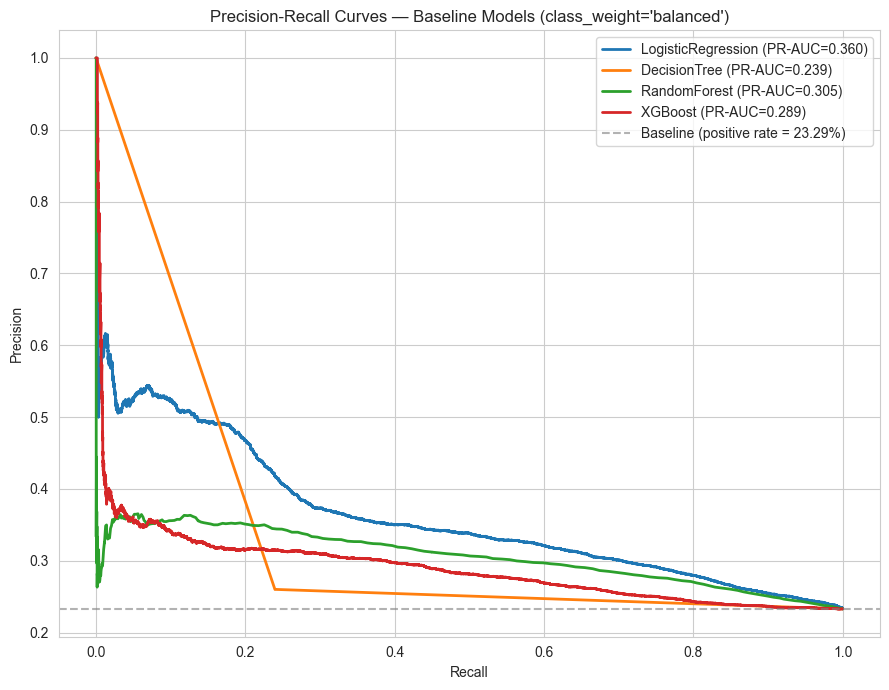

In [11]:
# Plot PR curves for all four baseline models
plt.figure(figsize=(9, 7))
positive_base_rate = y_val.mean()

for name, r in baseline_results.items():
    precision, recall, _ = precision_recall_curve(y_val, r["y_proba"])
    plt.plot(recall, precision, label=f"{name} (PR-AUC={r['pr_auc']:.3f})", linewidth=2)

plt.axhline(positive_base_rate, color="gray", linestyle="--", alpha=0.6,
            label=f"Baseline (positive rate = {positive_base_rate:.2%})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Baseline Models (class_weight='balanced')")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [12]:
# Summary table
baseline_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_proba", "y_pred", "fitted_model")}
    for r in baseline_results.values()
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("Baseline validation results (sorted by PR-AUC):")
print(baseline_summary.to_string(index=False))

Baseline validation results (sorted by PR-AUC):
             model   pr_auc  roc_auc   f1@0.5  precision@0.5  recall@0.5
LogisticRegression 0.360212 0.644068 0.419760       0.292445    0.743389
      RandomForest 0.305452 0.611721 0.068946       0.359420    0.038130
           XGBoost 0.288957 0.568667 0.362252       0.279231    0.515529
      DecisionTree 0.239363 0.516311 0.249700       0.260030    0.240160


# 9. Decision Threshold Tuning


In [13]:
def find_best_f1_threshold(y_true, y_proba):
    """Sweep thresholds from the PR curve, return the one that maximizes F1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    # precision/recall arrays are length N+1; thresholds is length N (last point has no threshold)
    # F1 = 2PR / (P+R), guard divide-by-zero
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    # Use the first N entries (those correspond to thresholds)
    best_idx = int(np.argmax(f1_scores[:-1]))
    return thresholds[best_idx], f1_scores[best_idx], precision[best_idx], recall[best_idx]


threshold_rows = []
for name, r in baseline_results.items():
    best_thr, best_f1, best_p, best_r = find_best_f1_threshold(y_val, r["y_proba"])
    threshold_rows.append({
        "model": name,
        "best_threshold": round(best_thr, 4),
        "f1@best": round(best_f1, 4),
        "precision@best": round(best_p, 4),
        "recall@best": round(best_r, 4),
        "f1@0.5": round(r["f1@0.5"], 4),
        "delta_f1": round(best_f1 - r["f1@0.5"], 4),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values("f1@best", ascending=False)
print("Threshold tuning results:")
print(threshold_df.to_string(index=False))

Threshold tuning results:
             model  best_threshold  f1@best  precision@best  recall@best  f1@0.5  delta_f1
LogisticRegression          0.5161   0.4212          0.3028       0.6913  0.4198    0.0014
      RandomForest          0.1367   0.4052          0.2756       0.7652  0.0689    0.3363
           XGBoost          0.0005   0.3779          0.2330       1.0000  0.3623    0.0156
      DecisionTree          0.0000   0.3778          0.2329       1.0000  0.2497    0.1281


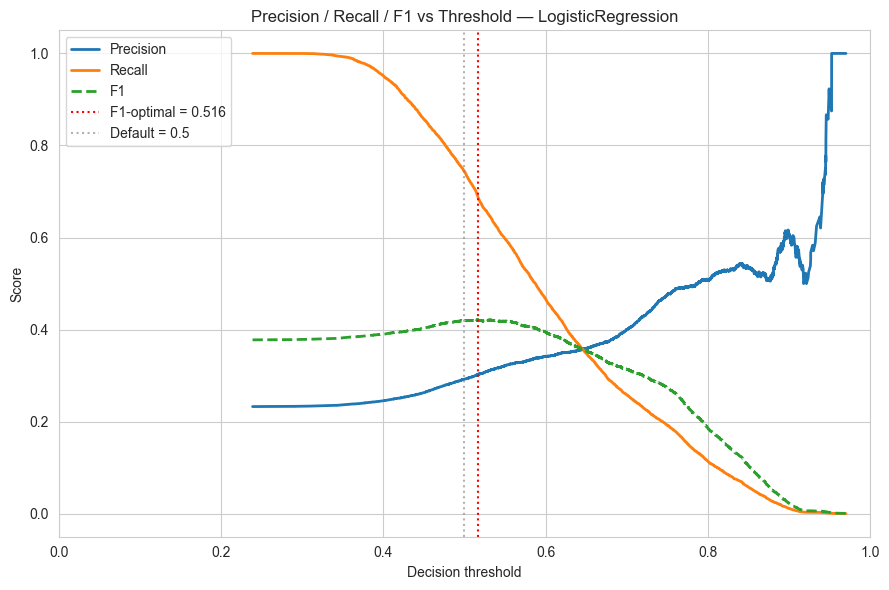

In [14]:
# Plot precision / recall / F1 vs threshold for the best baseline (by PR-AUC)
best_baseline_name = baseline_summary.iloc[0]["model"]
best_proba = baseline_results[best_baseline_name]["y_proba"]

precision, recall, thresholds = precision_recall_curve(y_val, best_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

# Trim to length of thresholds for plotting
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, precision[:-1], label="Precision", linewidth=2)
ax.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
ax.plot(thresholds, f1_scores[:-1], label="F1", linewidth=2, linestyle="--")

best_thr_row = threshold_df[threshold_df["model"] == best_baseline_name].iloc[0]
ax.axvline(best_thr_row["best_threshold"], color="red", linestyle=":",
           label=f"F1-optimal = {best_thr_row['best_threshold']:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.6, label="Default = 0.5")

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs Threshold — {best_baseline_name}")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

# 10. Class Imbalance — Option B: SMOTE


In [15]:
# SMOTE requires non-NaN input — use imputed training data for all models here
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)
print(f"After SMOTE: {X_train_smote.shape[0]:,} rows "
      f"({(y_train_smote == 1).sum():,} positives, "
      f"{(y_train_smote == 0).sum():,} negatives)")
print(f"New class balance: {y_train_smote.mean():.1%} positive")

# For Logistic Regression we also need to scale the SMOTE-resampled data.
# Important: refit the scaler on the resampled training data (the distribution changed).
X_train_smote_scaled = pd.DataFrame(
    scaler.transform(X_train_smote), columns=feature_cols
)
X_val_smote_scaled = X_val_scaled  # same val scaling as in Section 6

After SMOTE: 267,466 rows (133,733 positives, 133,733 negatives)
New class balance: 50.0% positive


In [16]:
# Models without class_weight / scale_pos_weight — let SMOTE do the balancing
models_smote = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, solver="liblinear", random_state=RANDOM_STATE
    ),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        tree_method="hist", eval_metric="logloss", n_jobs=1, random_state=RANDOM_STATE
    ),
}

fit_data_smote = {
    "LogisticRegression": (X_train_smote_scaled, X_val_smote_scaled),
    "DecisionTree":       (X_train_smote,        X_val_imp),
    "RandomForest":       (X_train_smote,        X_val_imp),
    "XGBoost":            (X_train_smote,        X_val_imp),  # imputed, since SMOTE needed imputed input
}

smote_results = {}
for name, model in models_smote.items():
    X_tr, X_va = fit_data_smote[name]
    print(f"Training {name} with SMOTE...")
    smote_results[name] = evaluate_on_val(name, model, X_tr, y_train_smote, X_va, y_val)
    r = smote_results[name]
    print(f"  PR-AUC={r['pr_auc']:.4f}  ROC-AUC={r['roc_auc']:.4f}  "
          f"F1={r['f1@0.5']:.4f}  P={r['precision@0.5']:.4f}  R={r['recall@0.5']:.4f}")

Training LogisticRegression with SMOTE...
  PR-AUC=0.3610  ROC-AUC=0.6449  F1=0.4203  P=0.2933  R=0.7411
Training DecisionTree with SMOTE...
  PR-AUC=0.2491  ROC-AUC=0.5375  F1=0.3049  P=0.2818  R=0.3321
Training RandomForest with SMOTE...
  PR-AUC=0.2953  ROC-AUC=0.6042  F1=0.1790  P=0.3246  R=0.1236
Training XGBoost with SMOTE...
  PR-AUC=0.3033  ROC-AUC=0.5905  F1=0.1954  P=0.3576  R=0.1344


In [17]:
# Compare class-weight vs SMOTE per model
comparison = pd.DataFrame({
    "model": list(baseline_results.keys()),
    "pr_auc_class_weight": [baseline_results[m]["pr_auc"] for m in baseline_results],
    "pr_auc_smote":        [smote_results[m]["pr_auc"]    for m in smote_results],
})
comparison["delta"] = comparison["pr_auc_smote"] - comparison["pr_auc_class_weight"]
comparison["winner"] = np.where(comparison["delta"] > 0, "SMOTE", "class_weight")
print("Class-weight vs SMOTE on validation PR-AUC:")
print(comparison.round(4).to_string(index=False))

class_weight_wins = (comparison["winner"] == "class_weight").sum()
smote_wins = (comparison["winner"] == "SMOTE").sum()
print(f"\nclass_weight wins: {class_weight_wins}/{len(comparison)} models")
print(f"SMOTE wins:        {smote_wins}/{len(comparison)} models")

if class_weight_wins >= smote_wins:
    CHOSEN_IMBALANCE = "class_weight"
    print("\nDecision: use class_weight / scale_pos_weight for hyperparameter tuning.")
    print("Rationale: equal or better PR-AUC on more models, preserves calibration,")
    print("and avoids synthetic samples in training.")
else:
    CHOSEN_IMBALANCE = "smote"
    print("\nDecision: use SMOTE for hyperparameter tuning.")
    print("Rationale: better validation PR-AUC on more models.")

Class-weight vs SMOTE on validation PR-AUC:
             model  pr_auc_class_weight  pr_auc_smote   delta       winner
LogisticRegression               0.3602        0.3610  0.0008        SMOTE
      DecisionTree               0.2394        0.2491  0.0097        SMOTE
      RandomForest               0.3055        0.2953 -0.0102 class_weight
           XGBoost               0.2890        0.3033  0.0143        SMOTE

class_weight wins: 1/4 models
SMOTE wins:        3/4 models

Decision: use SMOTE for hyperparameter tuning.
Rationale: better validation PR-AUC on more models.


# 11. Hyperparameter Tuning with GridSearchCV + TimeSeriesSplit


In [18]:
# Re-sort training data by GAME_DATE alone for TimeSeriesSplit
train_sorted_idx = train_df.sort_values("GAME_DATE").index

# Prepare sorted versions of every training input we might need
X_train_sorted       = X_train.loc[train_sorted_idx]          # raw (for XGBoost)
X_train_imp_sorted   = X_train_imp.loc[train_sorted_idx]       # imputed
X_train_scaled_sorted = X_train_scaled.loc[train_sorted_idx]   # scaled
y_train_sorted       = y_train.loc[train_sorted_idx]

# For SMOTE path, we only resample inside each fold would be more correct,
# but per the spec we tune with the chosen imbalance strategy.
# Here we apply the chosen strategy: class_weight / scale_pos_weight inside the estimator.

tscv = TimeSeriesSplit(n_splits=5)

# Show the fold structure so we can sanity-check that validation folds come after training folds
print("TimeSeriesSplit fold sizes (rows):")
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train_sorted), 1):
    tr_dates = (train_df.loc[X_train_sorted.index[tr_idx], "GAME_DATE"].min(),
                train_df.loc[X_train_sorted.index[tr_idx], "GAME_DATE"].max())
    va_dates = (train_df.loc[X_train_sorted.index[va_idx], "GAME_DATE"].min(),
                train_df.loc[X_train_sorted.index[va_idx], "GAME_DATE"].max())
    print(f"  Fold {i}: train n={len(tr_idx):>6} [{tr_dates[0].date()}..{tr_dates[1].date()}]  "
          f"| val n={len(va_idx):>6} [{va_dates[0].date()}..{va_dates[1].date()}]")

TimeSeriesSplit fold sizes (rows):
  Fold 1: train n= 26761 [2015-10-27..2016-04-25]  | val n= 26756 [2016-04-25..2017-04-09]
  Fold 2: train n= 53517 [2015-10-27..2017-04-09]  | val n= 26756 [2017-04-10..2018-04-01]
  Fold 3: train n= 80273 [2015-10-27..2018-04-01]  | val n= 26756 [2018-04-01..2019-03-24]
  Fold 4: train n=107029 [2015-10-27..2019-03-24]  | val n= 26756 [2019-03-24..2020-08-13]
  Fold 5: train n=133785 [2015-10-27..2020-08-13]  | val n= 26756 [2020-08-13..2021-07-20]


In [19]:
# Hyperparameter grids
param_grids = {
    "LogisticRegression": {
        "C": [0.001, 0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
    },
    "DecisionTree": {
        "max_depth": [3, 5, 7, 10],
        "min_samples_leaf": [10, 30, 50, 100],
    },
    "RandomForest": {
        "n_estimators": [300, 500], # [100, 300, 500]
        "max_depth": [10, 15, None],
        "min_samples_leaf": [10, 30, 50],
    },
    "XGBoost": {
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "n_estimators": [100, 300, 500],
        "min_child_weight": [5, 10, 20],
        "subsample": [0.7, 0.9],
    },
}

# Estimators to tune — each uses the imbalance handling from section 7
# (we picked class_weight above; if SMOTE had won we would use a different path,
# but per the spec we run GridSearchCV on the class_weight estimators either way
# because the SMOTE-inside-CV pipeline is not in scope).
#
# Note on LR solvers: lbfgs and saga both support class_weight. saga can be slower
# to converge on this dataset, so we set max_iter=5000 to avoid convergence warnings
# during grid search. liblinear is dropped here because it does not support all
# the multinomial / penalty options that the saga/lbfgs comparison exposes.
estimators_for_tuning = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=5000,
        random_state=RANDOM_STATE,
    ),
    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, tree_method="hist",
        eval_metric="logloss", n_jobs=1, random_state=RANDOM_STATE,
    ),
}

# Preprocessing level per model (sorted versions for CV)
tuning_data = {
    "LogisticRegression": X_train_scaled_sorted,
    "DecisionTree":       X_train_imp_sorted,
    "RandomForest":       X_train_imp_sorted,
    "XGBoost":            X_train_sorted,  # raw — XGB handles NaN
}

In [20]:
import time

tuning_results = {}

for name, estimator in estimators_for_tuning.items():
    print(f"\n=== Tuning {name} ===")
    X_tune = tuning_data[name]
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grids[name],
        scoring="average_precision",
        cv=tscv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    t0 = time.time()
    grid.fit(X_tune, y_train_sorted)
    elapsed = time.time() - t0
    print(f"  best params:    {grid.best_params_}")
    print(f"  best CV PR-AUC: {grid.best_score_:.4f}")
    print(f"  elapsed:        {elapsed:.1f}s")
    tuning_results[name] = {
        "best_params": grid.best_params_,
        "best_cv_pr_auc": grid.best_score_,
        "best_estimator": grid.best_estimator_,
    }


=== Tuning LogisticRegression ===
  best params:    {'C': 0.01, 'solver': 'saga'}
  best CV PR-AUC: 0.2444
  elapsed:        5.4s

=== Tuning DecisionTree ===
  best params:    {'max_depth': 5, 'min_samples_leaf': 50}
  best CV PR-AUC: 0.2314
  elapsed:        5.0s

=== Tuning RandomForest ===
  best params:    {'max_depth': 15, 'min_samples_leaf': 50, 'n_estimators': 500}
  best CV PR-AUC: 0.2519
  elapsed:        467.8s

=== Tuning XGBoost ===
  best params:    {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.7}
  best CV PR-AUC: 0.2559
  elapsed:        153.6s


took around 10 minutes (9 minutes and 58.5 seconds)

In [21]:
# Evaluate each tuned model on the held-out validation set (2021-22)
# The best_estimator_ has been refit on the full training set by GridSearchCV (refit=True).
tuned_val_results = {}
for name, tr in tuning_results.items():
    model = tr["best_estimator"]
    # Use the original (non-sorted) preprocessed validation matrices
    X_va = {
        "LogisticRegression": X_val_scaled,
        "DecisionTree":       X_val_imp,
        "RandomForest":       X_val_imp,
        "XGBoost":            X_val,
    }[name]
    y_proba = model.predict_proba(X_va)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    best_thr, best_f1, best_p, best_r = find_best_f1_threshold(y_val, y_proba)
    tuned_val_results[name] = {
        "model": name,
        "best_params": tr["best_params"],
        "cv_pr_auc": tr["best_cv_pr_auc"],
        "val_pr_auc": average_precision_score(y_val, y_proba),
        "val_roc_auc": roc_auc_score(y_val, y_proba),
        "val_f1@0.5": f1_score(y_val, y_pred),
        "val_f1@best_thr": best_f1,
        "best_threshold": best_thr,
        "val_precision@best": best_p,
        "val_recall@best": best_r,
        "y_proba": y_proba,
        "fitted_model": model,
    }

tuned_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_proba", "fitted_model")}
    for r in tuned_val_results.values()
]).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
print("Tuned model validation performance (sorted by val PR-AUC):")
print(tuned_summary.to_string(index=False))

Tuned model validation performance (sorted by val PR-AUC):
             model                                                                                            best_params  cv_pr_auc  val_pr_auc  val_roc_auc  val_f1@0.5  val_f1@best_thr  best_threshold  val_precision@best  val_recall@best
LogisticRegression                                                                          {'C': 0.01, 'solver': 'saga'}   0.244369    0.360322     0.644272    0.420572         0.421403        0.513558            0.301457         0.699877
           XGBoost {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.7}   0.255900    0.348961     0.645628    0.417122         0.420651        0.525748            0.299928         0.704028
      RandomForest                                         {'max_depth': 15, 'min_samples_leaf': 50, 'n_estimators': 500}   0.251883    0.338442     0.641106    0.417115         0.418706        0.480116            0.29185

# 12. Final Model Selection


In [22]:
# Full comparison: baseline class_weight, baseline SMOTE, tuned
all_results_rows = []
for name, r in baseline_results.items():
    all_results_rows.append({
        "model": name, "config": "baseline_class_weight",
        "val_pr_auc": r["pr_auc"], "val_f1@0.5": r["f1@0.5"],
    })
for name, r in smote_results.items():
    all_results_rows.append({
        "model": name, "config": "baseline_smote",
        "val_pr_auc": r["pr_auc"], "val_f1@0.5": r["f1@0.5"],
    })
for name, r in tuned_val_results.items():
    all_results_rows.append({
        "model": name, "config": "tuned_class_weight",
        "val_pr_auc": r["val_pr_auc"], "val_f1@0.5": r["val_f1@0.5"],
    })

all_results_df = (
    pd.DataFrame(all_results_rows)
    .sort_values("val_pr_auc", ascending=False)
    .reset_index(drop=True)
)
print("All experiments — validation PR-AUC (sorted):")
print(all_results_df.round(4).to_string(index=False))

All experiments — validation PR-AUC (sorted):
             model                config  val_pr_auc  val_f1@0.5
LogisticRegression        baseline_smote      0.3610      0.4203
LogisticRegression    tuned_class_weight      0.3603      0.4206
LogisticRegression baseline_class_weight      0.3602      0.4198
           XGBoost    tuned_class_weight      0.3490      0.4171
      RandomForest    tuned_class_weight      0.3384      0.4171
      DecisionTree    tuned_class_weight      0.3322      0.4190
      RandomForest baseline_class_weight      0.3055      0.0689
           XGBoost        baseline_smote      0.3033      0.1954
      RandomForest        baseline_smote      0.2953      0.1790
           XGBoost baseline_class_weight      0.2890      0.3623
      DecisionTree        baseline_smote      0.2491      0.3049
      DecisionTree baseline_class_weight      0.2394      0.2497


In [ ]:
# Select winner: best tuned model by validation PR-AUC
best_model_name = tuned_summary.iloc[0]["model"]
best_model_info = tuned_val_results[best_model_name]
best_threshold = float(best_model_info["best_threshold"])

print(f"\n=== Best Model based off of Validation Set Performance ===")
print(f"Model:             {best_model_name}")
print(f"Best hyperparams:  {best_model_info['best_params']}")
print(f"CV PR-AUC:         {best_model_info['cv_pr_auc']:.4f}")
print(f"Validation PR-AUC: {best_model_info['val_pr_auc']:.4f}")
print(f"Validation ROC-AUC:{best_model_info['val_roc_auc']:.4f}")
print(f"F1-optimal threshold: {best_threshold:.4f}")
print(f"  Precision @ best thr: {best_model_info['val_precision@best']:.4f}")
print(f"  Recall    @ best thr: {best_model_info['val_recall@best']:.4f}")
print(f"  F1        @ best thr: {best_model_info['val_f1@best_thr']:.4f}")

# Also flag the best interpretable model for comparison in the write-up
interpretable = {"LogisticRegression", "DecisionTree"}
interp_summary = tuned_summary[tuned_summary["model"].isin(interpretable)].head(1)
if len(interp_summary) > 0:
    interp_name = interp_summary.iloc[0]["model"]
    interp_pr_auc = interp_summary.iloc[0]["val_pr_auc"]
    gap = best_model_info["val_pr_auc"] - interp_pr_auc
    print(f"\nBest interpretable model: {interp_name}  (val PR-AUC={interp_pr_auc:.4f}, "
          f"gap vs best = {gap:+.4f})")


=== Best MODEL based off of Validation Set Performance ===
Model:             LogisticRegression
Best hyperparams:  {'C': 0.01, 'solver': 'saga'}
CV PR-AUC:         0.2444
Validation PR-AUC: 0.3603
Validation ROC-AUC:0.6443
F1-optimal threshold: 0.5136
  Precision @ best thr: 0.3015
  Recall    @ best thr: 0.6999
  F1        @ best thr: 0.4214

Best interpretable model: LogisticRegression  (val PR-AUC=0.3603, gap vs best = +0.0000)


### Model Comparison on the Validation Set

#### Analysis

The tuned validation PR-AUCs land within a narrow band: LR 0.360, XGBoost 0.349, RF 0.338, DT 0.332. The interpretable Logistic Regression model wins outright. This runs contrary to Lu et al. (2022), where XGBoost (AUC 0.840) beat logistic regression (AUC 0.818) on a similar NBA injury-prediction task. 

Two reasons likely explain the reversal:

1. **Different target definition.** Lu et al. predicted lower-extremity muscle strain specifically, using richer biomechanical and positional features. Our target is any workload-driven IL placement within 30 days, with minutes-based workload proxies only. Less structured signal for trees to exploit.
2. **Label noise pushed XGBoost toward heavy regularization.** The tuned XGBoost hyperparameters (`max_depth=3`, `min_child_weight=10`, `subsample=0.7`, `n_estimators=100`) describe a very conservative model — the grid selected these specifically because delayed IL placements inject noise that punishes deeper trees. A heavily regularized XGBoost behaves more like a linear model, which is why the gap vs. LR collapsed.

Interpretation: the injury signal available in our feature set is predominantly **linear and additive** at this dataset's noise level. Ensembles did not fail — they correctly identified that there wasn't enough non-linear signal to exploit past the noise floor. A richer feature set (GPS load, biomechanical markers, practice data) would likely widen the gap in favor of ensembles. For the stated research question — comparing interpretable vs. ensemble classifiers for medical-staff use — LR winning is a clean and favorable outcome: the model we'd want to deploy for its interpretability is also the model with the best held-out performance.

#### Note on the Model Comparison Analysis and its Limitation

This analysis is based on validation-set performance; however, the injury rate shows a clear upward trend across seasons, particularly in the validation period, 2021-22:

| Season   | Injury Rate |
|----------|------------|
| 2015-16  | 0.118007   |
| 2016-17  | 0.147987   |
| 2017-18  | 0.181870   |
| 2018-19  | 0.185721   |
| 2019-20  | 0.178791   |
| 2020-21  | 0.194237   |
| 2021-22  | 0.232893   |
|2022-23   | 0.208545   |


This distribution shift suggests that the validation data may not be fully representative of earlier seasons. As a result, model performance, especially metrics such as PR-AUC that are sensitive to class imbalance, may change on the test set. 

Therefore, model rankings should be interpreted with caution, as performance differences may reflect temporal changes in injury prevalence rather than purely model capability.


## 13. Feature Importance Analysis


Logistic Regression coefficients (signed, on standardized features):
games_last_7d              -0.2865
cumulative_season_min      -0.2445
rolling_14d_min            -0.0980
acwr_danger_zone           -0.0288
rest_days                  -0.0118
age                        -0.0108
is_back_to_back             0.0118
recent_quadriceps_injury    0.0194
recent_groin_injury         0.0222
rolling_5game_min           0.0243
recent_achilles_injury      0.0371
recent_foot_injury          0.0386
recent_hip_injury           0.0490
recent_ankle_injury         0.0504
recent_hamstring_injury     0.0514
recent_calf_injury          0.0569
recent_knee_injury          0.0573
acwr                        0.0588
recent_back_injury          0.0665
rolling_28d_min             0.1013
prior_injury_count          0.2859
rolling_7d_min              0.3040


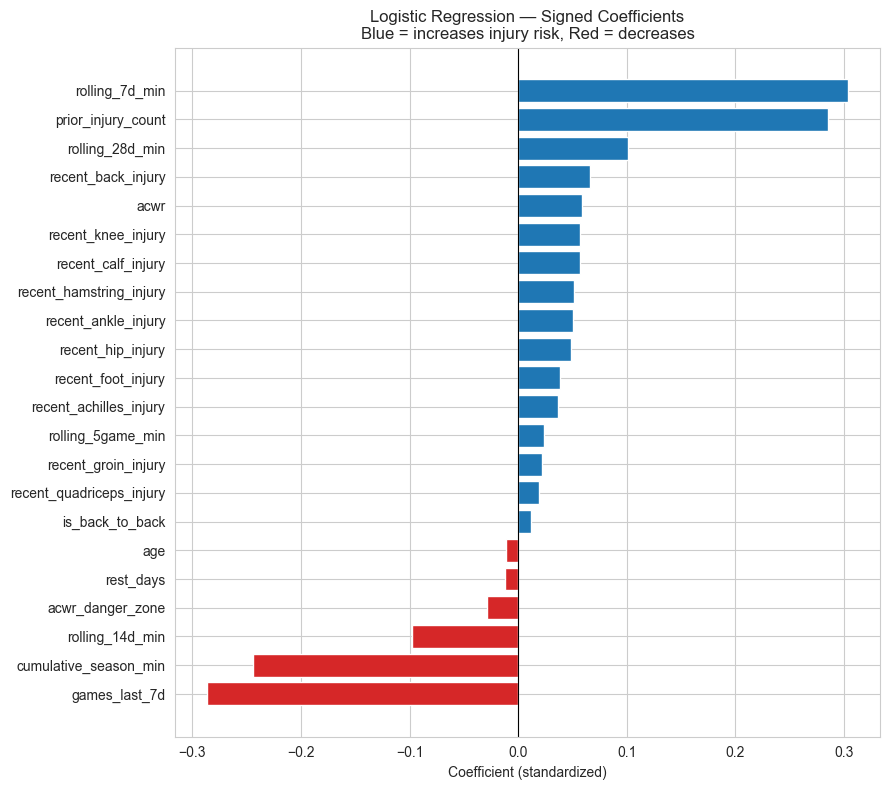

In [ ]:
# --- 13a. Logistic Regression coefficients (signed, standardized scale) ---
lr_model = tuned_val_results["LogisticRegression"]["fitted_model"]
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values()

print("Logistic Regression coefficients (signed, on standardized features):")
print(lr_coefs.round(4).to_string())

# Horizontal bar chart: blue = positive (increases risk), red = negative (decreases)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#1f77b4" if v >= 0 else "#d62728" for v in lr_coefs.values]
ax.barh(lr_coefs.index, lr_coefs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized)")
ax.set_title("Logistic Regression — Signed Coefficients\nBlue = increases injury risk, Red = decreases")
plt.tight_layout()
plt.savefig("../docs/reports/images/LR_coefficients_val.png", dpi=300, bbox_inches="tight")
plt.show()

Random Forest feature importances (top 10):
prior_injury_count       0.2900
cumulative_season_min    0.1464
age                      0.1448
rolling_5game_min        0.1093
rolling_28d_min          0.0776
rolling_14d_min          0.0618
rolling_7d_min           0.0494
acwr                     0.0443
games_last_7d            0.0131
rest_days                0.0123

XGBoost feature importances (top 10):
prior_injury_count       0.2745
rolling_5game_min        0.0848
cumulative_season_min    0.0732
acwr                     0.0592
recent_back_injury       0.0566
rolling_14d_min          0.0515
rolling_28d_min          0.0477
age                      0.0470
recent_hip_injury        0.0440
games_last_7d            0.0416


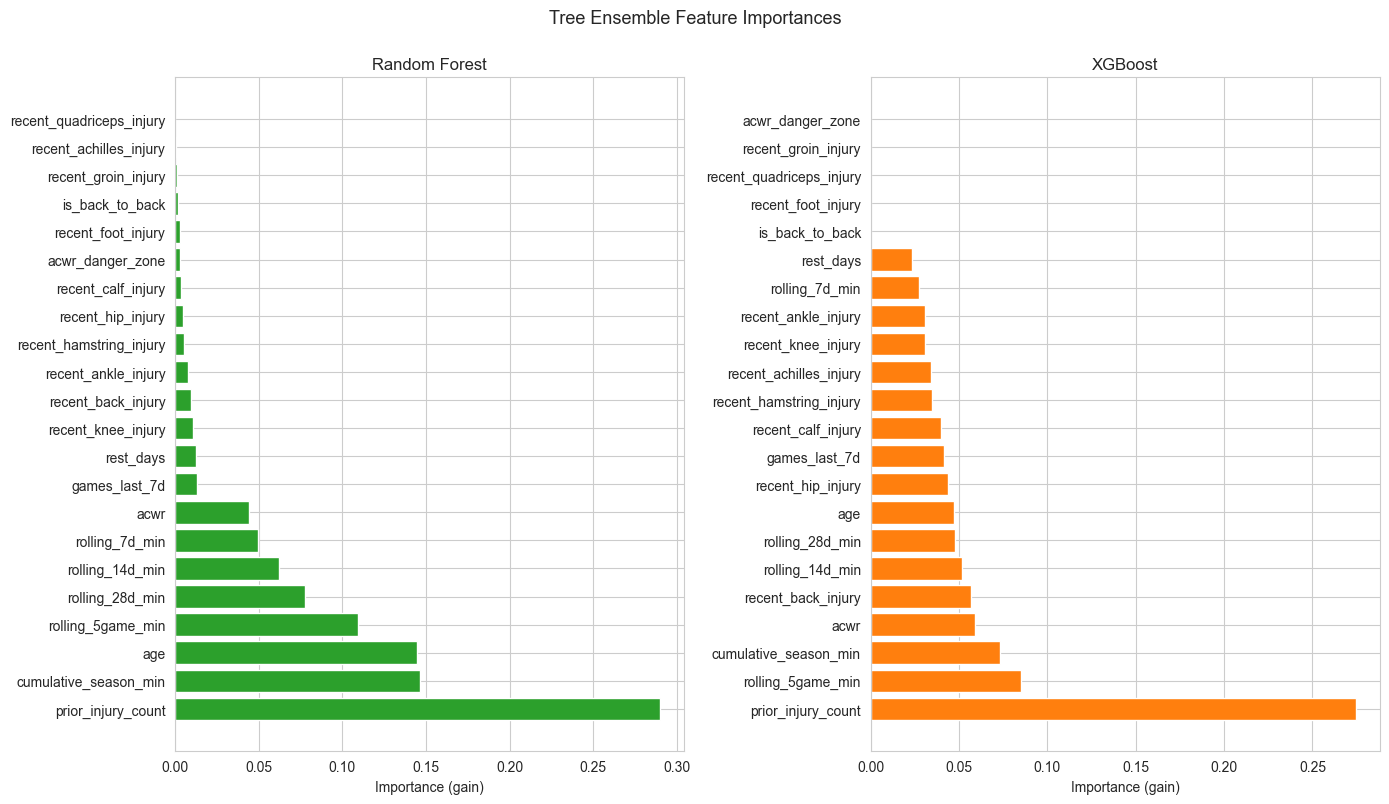

In [ ]:
# --- 13b. Random Forest and XGBoost feature importances (gain-based) ---
rf_model = tuned_val_results["RandomForest"]["fitted_model"]
xgb_model = tuned_val_results["XGBoost"]["fitted_model"]

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

print("Random Forest feature importances (top 10):")
print(rf_importances.sort_values(ascending=False).head(10).round(4).to_string())
print("\nXGBoost feature importances (top 10):")
print(xgb_importances.sort_values(ascending=False).head(10).round(4).to_string())

# Side-by-side horizontal bars, highest at top
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)

axes[0].barh(rf_importances.index, rf_importances.values, color="#2ca02c")
axes[0].invert_yaxis()
axes[0].set_xlabel("Importance (gain)")
axes[0].set_title("Random Forest")

axes[1].barh(xgb_importances.index, xgb_importances.values, color="#ff7f0e")
axes[1].invert_yaxis()
axes[1].set_xlabel("Importance (gain)")
axes[1].set_title("XGBoost")

fig.suptitle("Tree Ensemble Feature Importances", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("../docs/reports/images/ensemble_feature_importances_val.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# --- 13c. Grouped importance: workload vs. injury history vs. age ---
workload_features = [
    "rest_days", "is_back_to_back", "rolling_7d_min", "rolling_14d_min",
    "rolling_28d_min", "rolling_5game_min", "games_last_7d",
    "cumulative_season_min", "acwr", "acwr_danger_zone",
]
injury_history_features = [
    "prior_injury_count", "recent_hamstring_injury", "recent_quadriceps_injury",
    "recent_calf_injury", "recent_groin_injury", "recent_ankle_injury",
    "recent_achilles_injury", "recent_knee_injury", "recent_back_injury",
    "recent_hip_injury", "recent_foot_injury",
]
other = ["age"]

# Sanity check: every feature is in exactly one group
all_grouped = set(workload_features) | set(injury_history_features) | set(other)
assert all_grouped == set(feature_cols), \
    f"Group coverage mismatch: missing={set(feature_cols) - all_grouped}, extra={all_grouped - set(feature_cols)}"

def group_sums(importance_series):
    return {
        "workload": float(importance_series.loc[workload_features].sum()),
        "injury_history": float(importance_series.loc[injury_history_features].sum()),
        "age": float(importance_series.loc[other].sum()),
    }

rf_grouped = group_sums(rf_importances)
xgb_grouped = group_sums(xgb_importances)

grouped_df = pd.DataFrame({
    "RandomForest": rf_grouped,
    "XGBoost": xgb_grouped,
})
grouped_df.loc["TOTAL"] = grouped_df.sum()
grouped_df["RF_pct"] = (grouped_df["RandomForest"] / grouped_df.loc["TOTAL", "RandomForest"] * 100).round(1)
grouped_df["XGB_pct"] = (grouped_df["XGBoost"] / grouped_df.loc["TOTAL", "XGBoost"] * 100).round(1)

print("Grouped feature importance (summed gain per group):")
print(grouped_df.round(4).to_string())

print("\nQuick read:")
for group in ["workload", "injury_history", "age"]:
    rf_p = grouped_df.loc[group, "RF_pct"]
    xg_p = grouped_df.loc[group, "XGB_pct"]
    print(f"  {group:>16}:  RF {rf_p:>5.1f}%   XGB {xg_p:>5.1f}%")

Grouped feature importance (summed gain per group):
                RandomForest  XGBoost  RF_pct  XGB_pct
workload              0.5192   0.4084    51.9     40.8
injury_history        0.3361   0.5447    33.6     54.5
age                   0.1448   0.0470    14.5      4.7
TOTAL                 1.0000   1.0000   100.0    100.0

Quick read:
          workload:  RF  51.9%   XGB  40.8%
    injury_history:  RF  33.6%   XGB  54.5%
               age:  RF  14.5%   XGB   4.7%


### 13d. Workload feature correlation check

The LR coefficient plot in 13a shows counterintuitive negative signs on `games_last_7d` (-0.29), `cumulative_season_min` (-0.24), and `rolling_14d_min` (-0.10). Taken at face value, these say that *more* games and *more* cumulative minutes *decrease* predicted injury risk — which contradicts the workload-load-injury mechanism of Bourdon et al. (2017) and Comas et al. (2022).

Before accepting or dismissing those signs, we check for multicollinearity among the workload features. Logistic Regression with L2 regularization redistributes coefficients unpredictably when predictors are highly correlated — individual signs stop being interpretable, only the net effect of the correlated group is. A correlation heatmap shows whether that's what's happening here.

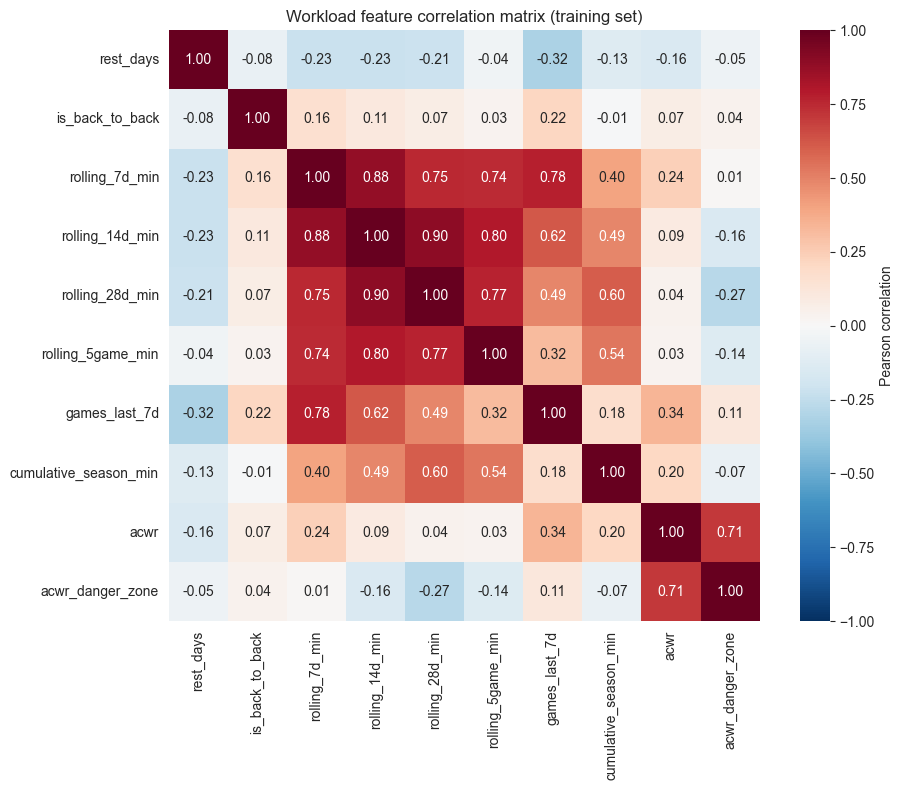


Workload feature pairs with |corr| >= 0.85: 2
      feature_a       feature_b  corr
rolling_14d_min rolling_28d_min 0.898
 rolling_7d_min rolling_14d_min 0.877


In [27]:
# Correlation heatmap for the 10 workload features (on imputed training data)
workload_corr = X_train_imp[workload_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    workload_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Workload feature correlation matrix (training set)")
plt.tight_layout()
plt.show()

# Flag the pairs with |corr| >= 0.85 — these are the likely culprits for
# the counterintuitive LR signs.
corr_pairs = (
    workload_corr.where(~np.eye(len(workload_corr), dtype=bool))  # drop diagonal
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_a", "feature_b", "corr"]
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
# Deduplicate (a,b) vs (b,a)
corr_pairs["pair"] = corr_pairs.apply(
    lambda r: tuple(sorted([r["feature_a"], r["feature_b"]])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates(subset="pair").drop(columns="pair")

high_corr = corr_pairs[corr_pairs["abs_corr"] >= 0.85].sort_values("abs_corr", ascending=False)
print(f"\nWorkload feature pairs with |corr| >= 0.85: {len(high_corr)}")
if len(high_corr) > 0:
    print(high_corr[["feature_a", "feature_b", "corr"]].round(3).to_string(index=False))
else:
    print("None — multicollinearity is not the explanation.")

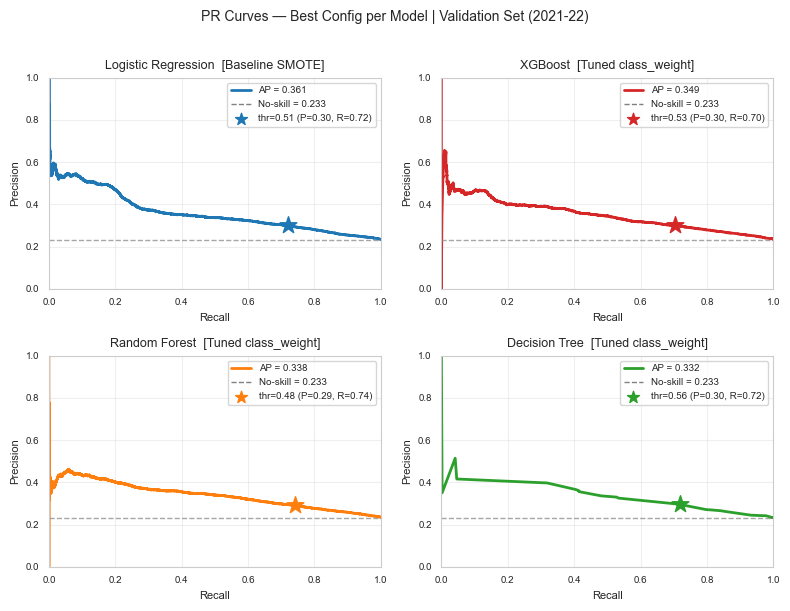

In [53]:
# =============================================================================
# PR Curves — Best configuration per model, Validation Set (2021-22)
# 2x2 grid, one panel per model
# =============================================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

positive_base_rate = y_val.mean()

MODEL_COLORS = {
    "LogisticRegression": "#1f77b4",
    "DecisionTree":       "#2ca02c",
    "RandomForest":       "#ff7f0e",
    "XGBoost":            "#d62728",
}

best_per_model = {
    "Logistic Regression": {
        "y_proba":        smote_results["LogisticRegression"]["y_proba"],
        "config":         "Baseline SMOTE",
        "best_threshold": find_best_f1_threshold(
            y_val, smote_results["LogisticRegression"]["y_proba"]
        )[0],
        "color":          MODEL_COLORS["LogisticRegression"],
    },
    "XGBoost": {
        "y_proba":        tuned_val_results["XGBoost"]["y_proba"],
        "config":         "Tuned class_weight",
        "best_threshold": tuned_val_results["XGBoost"]["best_threshold"],
        "color":          MODEL_COLORS["XGBoost"],
    },
    "Random Forest": {
        "y_proba":        tuned_val_results["RandomForest"]["y_proba"],
        "config":         "Tuned class_weight",
        "best_threshold": tuned_val_results["RandomForest"]["best_threshold"],
        "color":          MODEL_COLORS["RandomForest"],
    },
    "Decision Tree": {
        "y_proba":        tuned_val_results["DecisionTree"]["y_proba"],
        "config":         "Tuned class_weight",
        "best_threshold": tuned_val_results["DecisionTree"]["best_threshold"],
        "color":          MODEL_COLORS["DecisionTree"],
    },
}

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for ax, (name, info) in zip(axes, best_per_model.items()):
    y_proba  = info["y_proba"]
    best_thr = info["best_threshold"]
    color    = info["color"]

    precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    _, best_f1, best_p, best_r = find_best_f1_threshold(y_val, y_proba)

    ax.plot(recall, precision, color=color, linewidth=2)
    ax.axhline(positive_base_rate, color="gray", linestyle="--",
               linewidth=1, alpha=0.7)

    # F1-optimal operating point
    thr_idx = int(np.argmin(np.abs(thresholds - best_thr)))
    ax.scatter(recall[thr_idx], precision[thr_idx],
               color=color, marker="*", s=160, zorder=5)

    ax.set_title(f"{name}  [{info['config']}]", fontsize=9)
    ax.set_xlabel("Recall", fontsize=8)
    ax.set_ylabel("Precision", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    ax.legend(
        handles=[
            plt.Line2D([0], [0], color=color, linewidth=2,
                       label=f"AP = {ap:.3f}"),
            plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1,
                       label=f"No-skill = {positive_base_rate:.3f}"),
            plt.scatter([], [], marker="*", color=color, s=80,
                        label=f"thr={best_thr:.2f} (P={best_p:.2f}, R={best_r:.2f})"),
        ],
        fontsize=7, loc="upper right", framealpha=0.8,
    )

fig.suptitle(
    "PR Curves — Best Config per Model | Validation Set (2021-22)",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig("../docs/reports/images/pr_curves_validation.png", dpi=300, bbox_inches="tight")
plt.show()

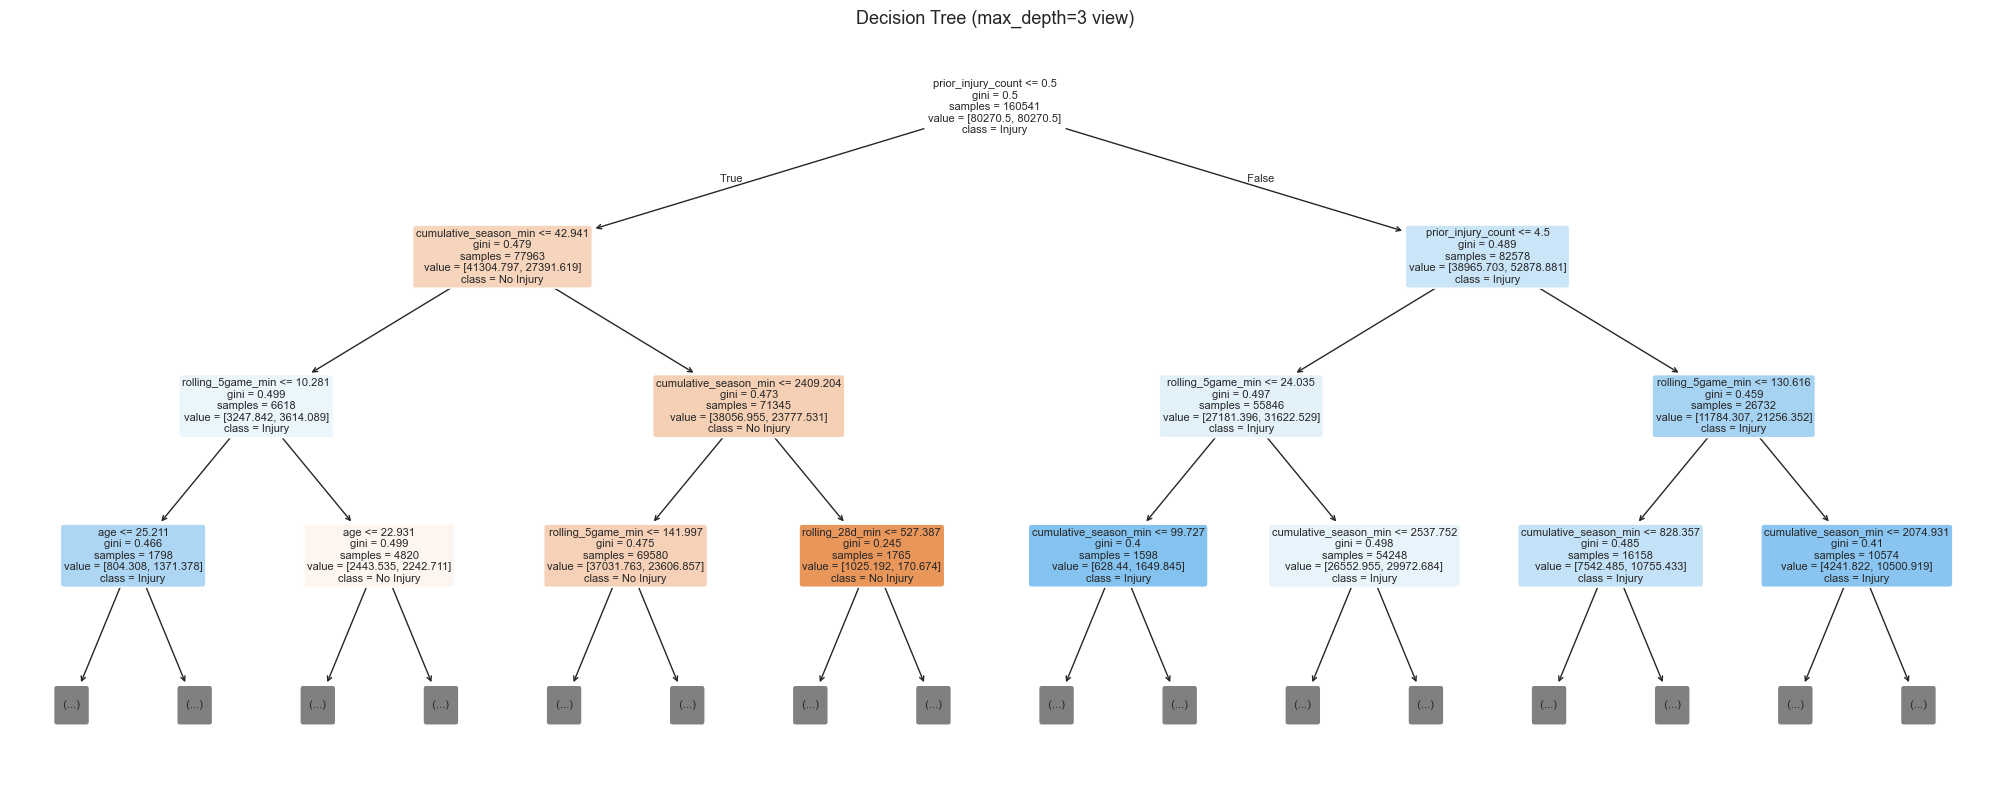

In [ ]:
# =============================================================================
# Decision Tree, Validation Set (2021-22)
# Max Depth 3
# =============================================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model = tuned_val_results["DecisionTree"]["fitted_model"]

# Check if it's a Pipeline and unwrap if needed
if hasattr(dt_model, "named_steps"):
    dt_model = dt_model.named_steps[list(dt_model.named_steps.keys())[-1]]

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X_val.columns.tolist(),
    class_names=["No Injury", "Injury"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
    ax=ax,
)
plt.title("Decision Tree (max_depth=3 view)", fontsize=13)
plt.tight_layout()
plt.show()

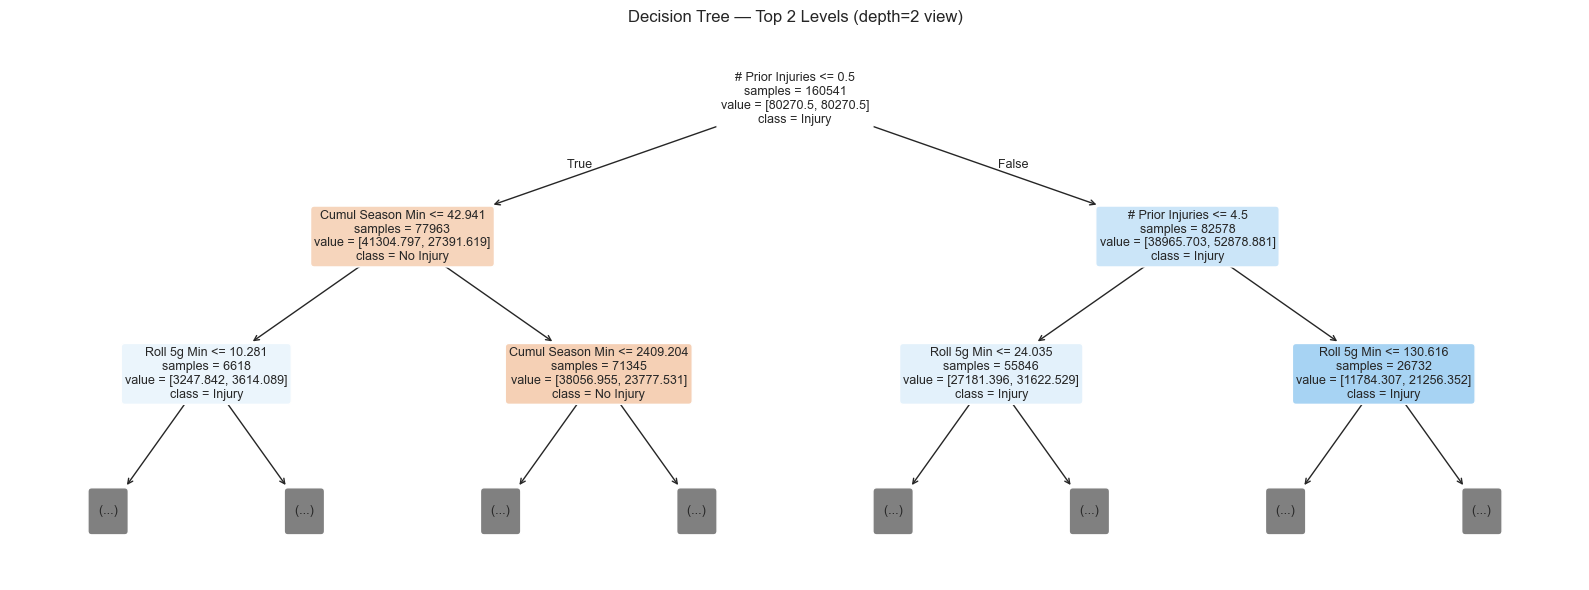

In [40]:
# =============================================================================
# Decision Tree, Validation Set (2021-22)
# Max Depth 2
# =============================================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Shortened feature names for readability
feature_name_map = {
    "age": "Age",
    "rest_days": "Rest Days",
    "is_back_to_back": "B2B",
    "rolling_7d_min": "Roll 7d Min",
    "rolling_14d_min": "Roll 14d Min",
    "rolling_28d_min": "Roll 28d Min",
    "games_last_7d": "Games 7d",
    "rolling_5game_min": "Roll 5g Min",
    "cumulative_season_min": "Cumul Season Min",
    "acwr": "ACWR",
    "acwr_danger_zone": "ACWR Danger",
    "prior_injury_count": "# Prior Injuries",
    "recent_hamstring_injury": "Hamstring Y/N",
    "recent_quadriceps_injury": "Rec Quad Inj Y/N",
    "recent_calf_injury": "Calf",
    "recent_groin_injury": "Groin",
    "recent_ankle_injury": "Ankle",
    "recent_achilles_injury": "Achilles",
    "recent_knee_injury": "Knee",
    "recent_back_injury": "Back",
    "recent_hip_injury": "Hip",
    "recent_foot_injury": "Foot",
}

short_names = [feature_name_map[f] for f in X_val.columns.tolist()]

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    dt_model,
    feature_names=short_names,
    class_names=["No Injury", "Injury"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=2,          # clean 2-level view: 1 root + 2 levels of splits
    impurity=False,       # hides gini to reduce clutter
    proportion=False,
    ax=ax,
)
plt.title("Decision Tree — Top 2 Levels (depth=2 view)", fontsize=12)
plt.tight_layout()
plt.show()

# 14. Final Model Preparation

In [ ]:
# --- Refit each model on train+val, then score on test ---

# Preprocessing (imputer/scaler already fit on X_train — refit now on train+val)
final_imputer = SimpleImputer(strategy="constant", fill_value=0)
X_trainval_raw = pd.concat([X_train, X_val])
y_trainval     = pd.concat([y_train, y_val])

X_trainval_imp = pd.DataFrame(
    final_imputer.fit_transform(X_trainval_raw), columns=feature_cols, index=X_trainval_raw.index
)
final_scaler = StandardScaler()
X_trainval_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_trainval_imp), columns=feature_cols, index=X_trainval_imp.index
)

# Preprocess test set with the new imputer/scaler
X_test_imp = pd.DataFrame(
    final_imputer.transform(X_test), columns=feature_cols, index=X_test.index
)
X_test_scaled = pd.DataFrame(
    final_scaler.transform(X_test_imp), columns=feature_cols, index=X_test_imp.index
)

             model  val_pr_auc  test_pr_auc  val_f1  test_f1  test_precision  test_recall
           XGBoost      0.3490       0.3963  0.4207   0.4267          0.2945       0.7740
      RandomForest      0.3384       0.3905  0.4187   0.4228          0.2871       0.8017
LogisticRegression      0.3603       0.3657  0.4214   0.4256          0.2975       0.7470
      DecisionTree      0.3322       0.3467  0.4192   0.4291          0.3034       0.7326


In [55]:
from sklearn.base import clone

results = []
test_probas = {}   # <-- store y_proba per model for PR curves
test_models = {}

for name, info in tuned_val_results.items():
    thr = info["best_threshold"]

    if name == "LogisticRegression":
        X_tr, X_te = X_trainval_scaled, X_test_scaled
    elif name in ("DecisionTree", "RandomForest"):
        X_tr, X_te = X_trainval_imp,    X_test_imp
    else:  # XGBoost
        X_tr, X_te = X_trainval_raw,    X_test

    model = clone(info["fitted_model"])
    if name == "XGBoost":
        spw = (y_trainval == 0).sum() / (y_trainval == 1).sum()
        model.set_params(scale_pos_weight=spw)

    model.fit(X_tr, y_trainval)
    test_models[name] = model

    test_proba = model.predict_proba(X_te)[:, 1]
    test_pred  = (test_proba >= thr).astype(int)

    test_probas[name] = test_proba   # <-- save it

    results.append({
        "model":          name,
        "best_threshold": thr,       # <-- keep threshold too
        "val_pr_auc":     info["val_pr_auc"],
        "test_pr_auc":    average_precision_score(y_test, test_proba),
        "val_f1":         info["val_f1@best_thr"],
        "test_f1":        f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred),
        "test_recall":    recall_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).sort_values("test_pr_auc", ascending=False)
print(results_df.round(4).to_string(index=False))

             model  best_threshold  val_pr_auc  test_pr_auc  val_f1  test_f1  test_precision  test_recall
           XGBoost          0.5257      0.3490       0.3963  0.4207   0.4267          0.2945       0.7740
      RandomForest          0.4801      0.3384       0.3905  0.4187   0.4228          0.2871       0.8017
LogisticRegression          0.5136      0.3603       0.3657  0.4214   0.4256          0.2975       0.7470
      DecisionTree          0.5610      0.3322       0.3467  0.4192   0.4291          0.3034       0.7326


In [85]:
# =============================================================================
# Feature Importance — Ensemble Models (Random Forest & XGBoost)
# Signed Logistic Regression Coefficients
# Test Set (2022-23)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Short feature names for readability
feature_name_map = {
    "age": "Age",
    "rest_days": "Rest Days",
    "is_back_to_back": "B2B",
    "rolling_7d_min": "Roll 7d Min",
    "rolling_14d_min": "Roll 14d Min",
    "rolling_28d_min": "Roll 28d Min",
    "games_last_7d": "Games 7d",
    "rolling_5game_min": "Roll 5g Min",
    "cumulative_season_min": "Season Min",
    "acwr": "ACWR",
    "acwr_danger_zone": "ACWR Danger",
    "prior_injury_count": "Prior Injury Count",
    "recent_hamstring_injury": "Hamstring",
    "recent_quadriceps_injury": "Quad",
    "recent_calf_injury": "Recent Calf Injury",
    "recent_groin_injury": "Recent Groin Injury",
    "recent_ankle_injury": "Recent Ankle Injury",
    "recent_achilles_injury": "Recent Achilles Injury",
    "recent_knee_injury": "Recent Knee Injury",
    "recent_back_injury": "Recent Back Injury",
    "recent_hip_injury": "Recent Hip Injury",
    "recent_foot_injury": "Recent Foot Injury",
}

short_names = [feature_name_map[f] for f in feature_cols]

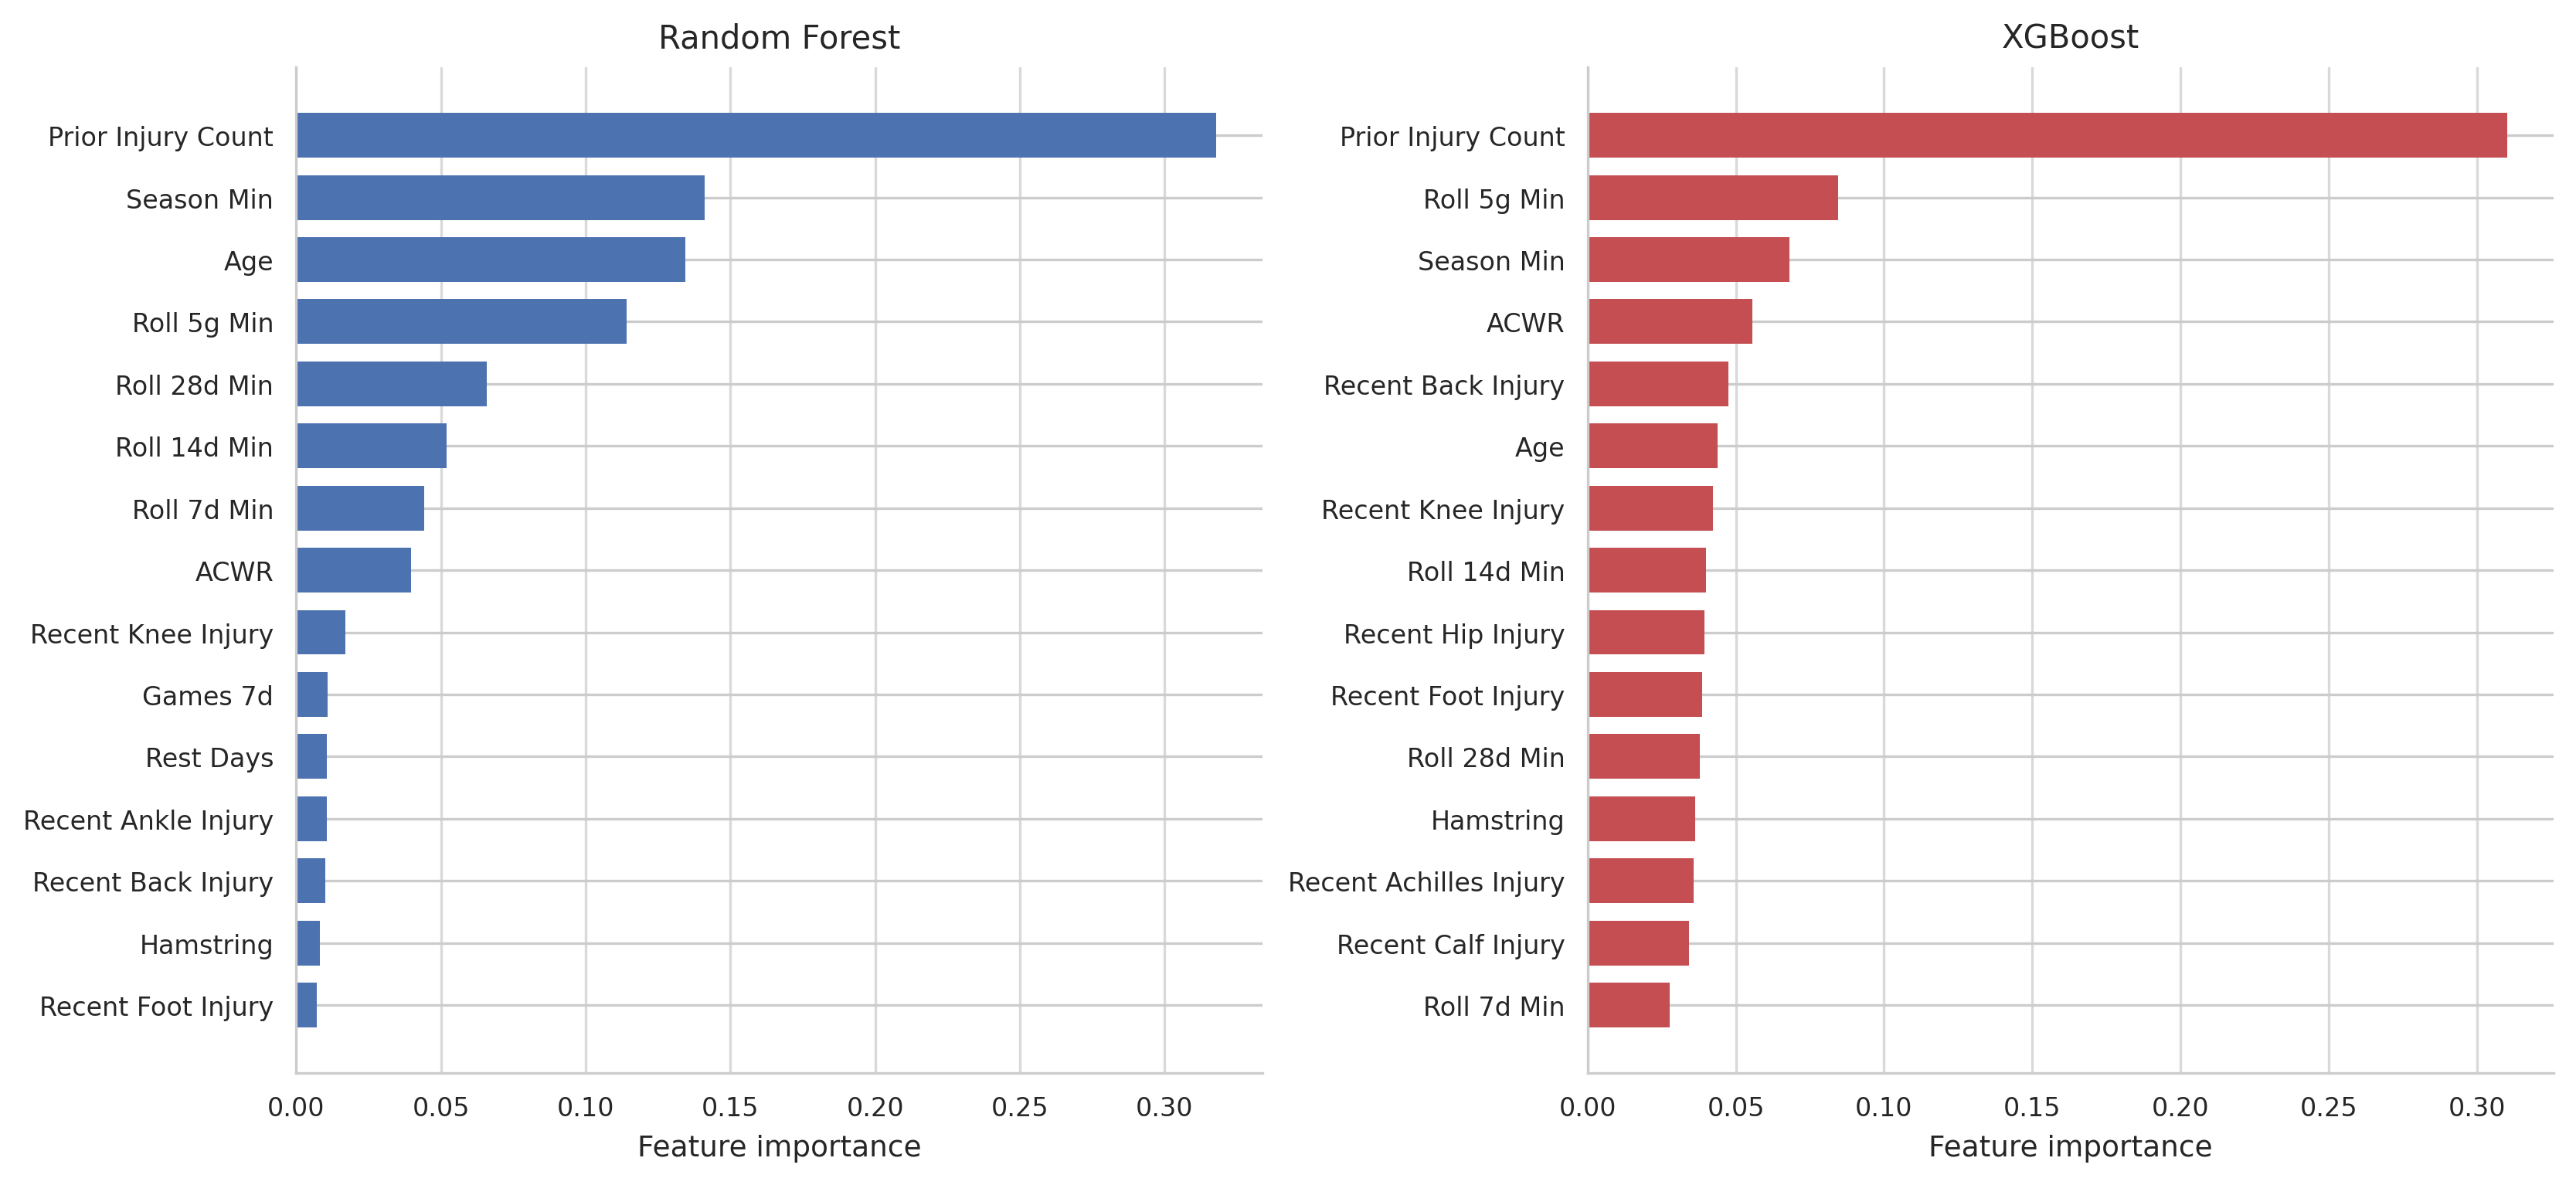

In [86]:
TOP_N = 15  # how many features to show per plot

# ------------------------------------------------------------------
# 1. Random Forest feature importance
# ------------------------------------------------------------------
rf_model = test_models["RandomForest"]
rf_imp = pd.Series(rf_model.feature_importances_, index=short_names) \
           .sort_values(ascending=False).head(TOP_N)

# ------------------------------------------------------------------
# 2. XGBoost feature importance
# ------------------------------------------------------------------
xgb_model = test_models["XGBoost"]
xgb_imp = pd.Series(xgb_model.feature_importances_, index=short_names) \
            .sort_values(ascending=False).head(TOP_N)

# ------------------------------------------------------------------
# Publication-style defaults
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ------------------------------------------------------------------
# Plot: 1x2 panels
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

# Shared styling
for ax in axes:
    ax.grid(axis="x", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# --- Random Forest ---
ax = axes[0]
ax.barh(
    rf_imp.index[::-1],
    rf_imp.values[::-1],
    color="#4C72B0",
    edgecolor="none",
    height=0.72,
)
ax.set_title("Random Forest")
ax.set_xlabel("Feature importance")
ax.tick_params(labelsize=8)

# --- XGBoost ---
ax = axes[1]
ax.barh(
    xgb_imp.index[::-1],
    xgb_imp.values[::-1],
    color="#C44E52",
    edgecolor="none",
    height=0.72,
)
ax.set_title("XGBoost")
ax.set_xlabel("Feature importance")
ax.tick_params(labelsize=8)

# fig.suptitle("Ensemble Feature Importance (Test Set, 2022–23)", fontsize=11)
plt.savefig(
    "../docs/reports/images/ensemble_feature_importances_test.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

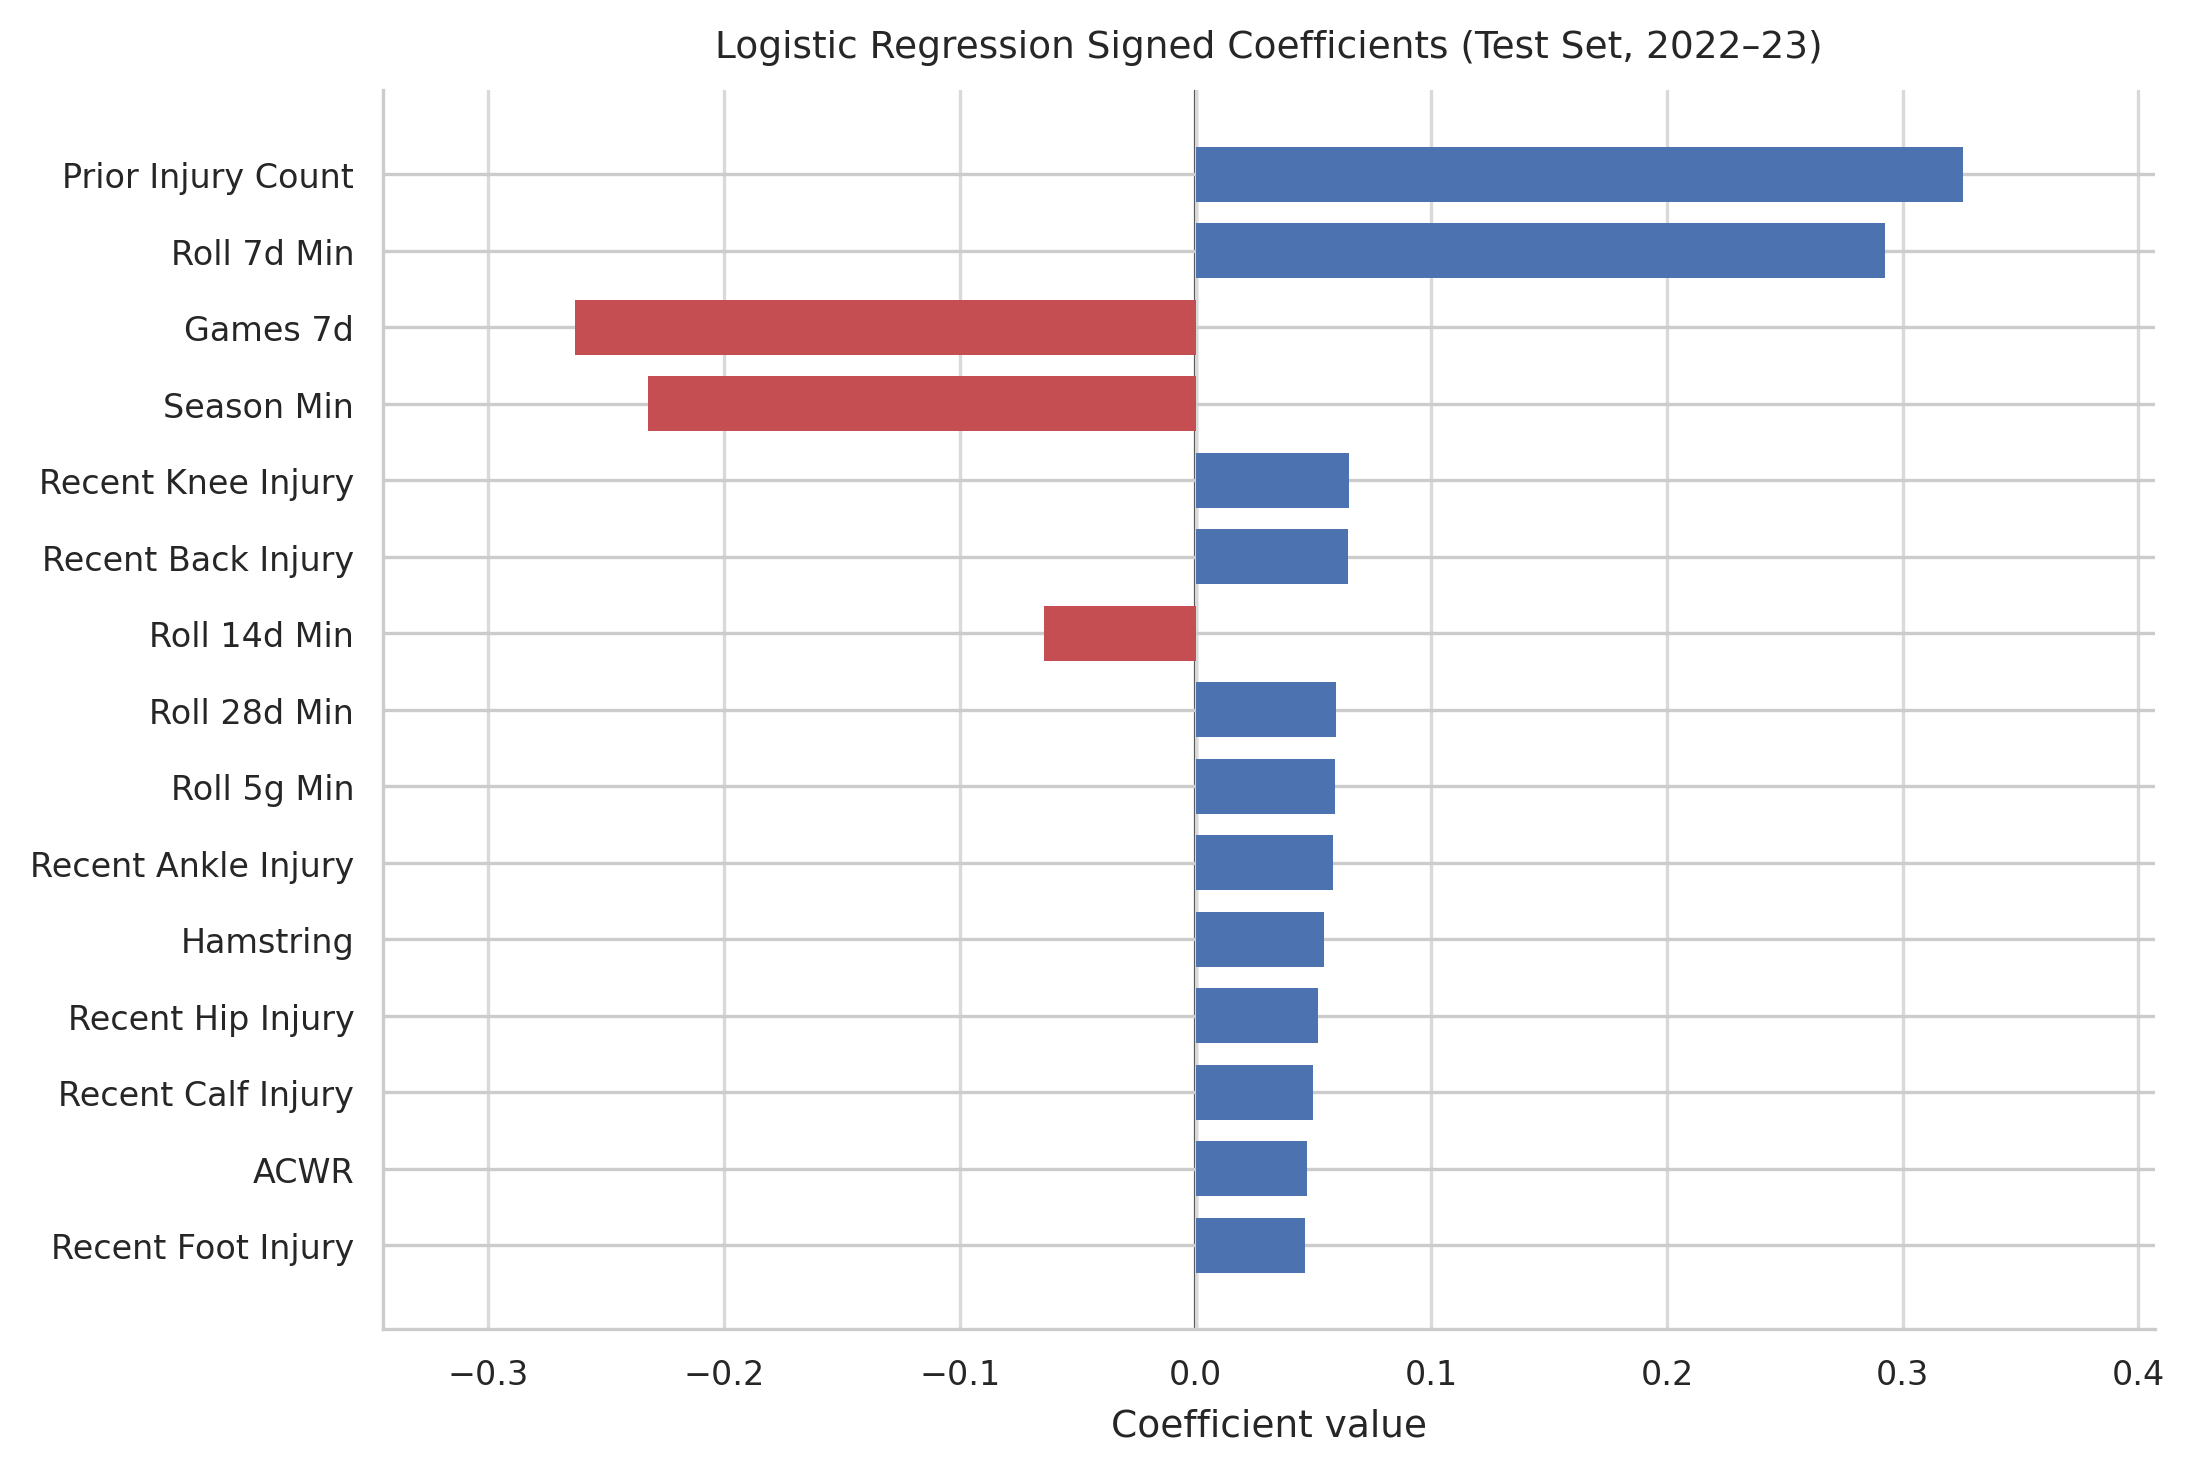

In [87]:
# =============================================================================
# Logistic Regression Signed Coefficients — Test Set (2022-23)
# =============================================================================

import matplotlib.pyplot as plt

lr_model = test_models["LogisticRegression"]
lr_coef = pd.Series(lr_model.coef_[0], index=short_names)

# Keep top-N by absolute magnitude, but preserve sign for plotting
lr_coef = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(TOP_N).index)

# Publication-style defaults
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)

# Muted, colorblind-friendlier palette
pos_color = "#4C72B0"  # muted blue
neg_color = "#C44E52"  # muted red

colors = [pos_color if v > 0 else neg_color for v in lr_coef.values]

ax.barh(
    lr_coef.index[::-1],
    lr_coef.values[::-1],
    color=colors[::-1],
    edgecolor="none",
    height=0.72,
)

ax.axvline(0, color="0.25", linewidth=1.0, zorder=0)

ax.set_title("Logistic Regression Signed Coefficients (Test Set, 2022–23)", pad=8)
ax.set_xlabel("Coefficient value")

ax.grid(axis="x", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)

# Clean publication look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: add a little extra x-padding for readability
xmin, xmax = ax.get_xlim()
pad = 0.08 * (xmax - xmin)
ax.set_xlim(xmin - pad, xmax + pad)

plt.savefig(
    "../docs/reports/images/LR_coefficients_test.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

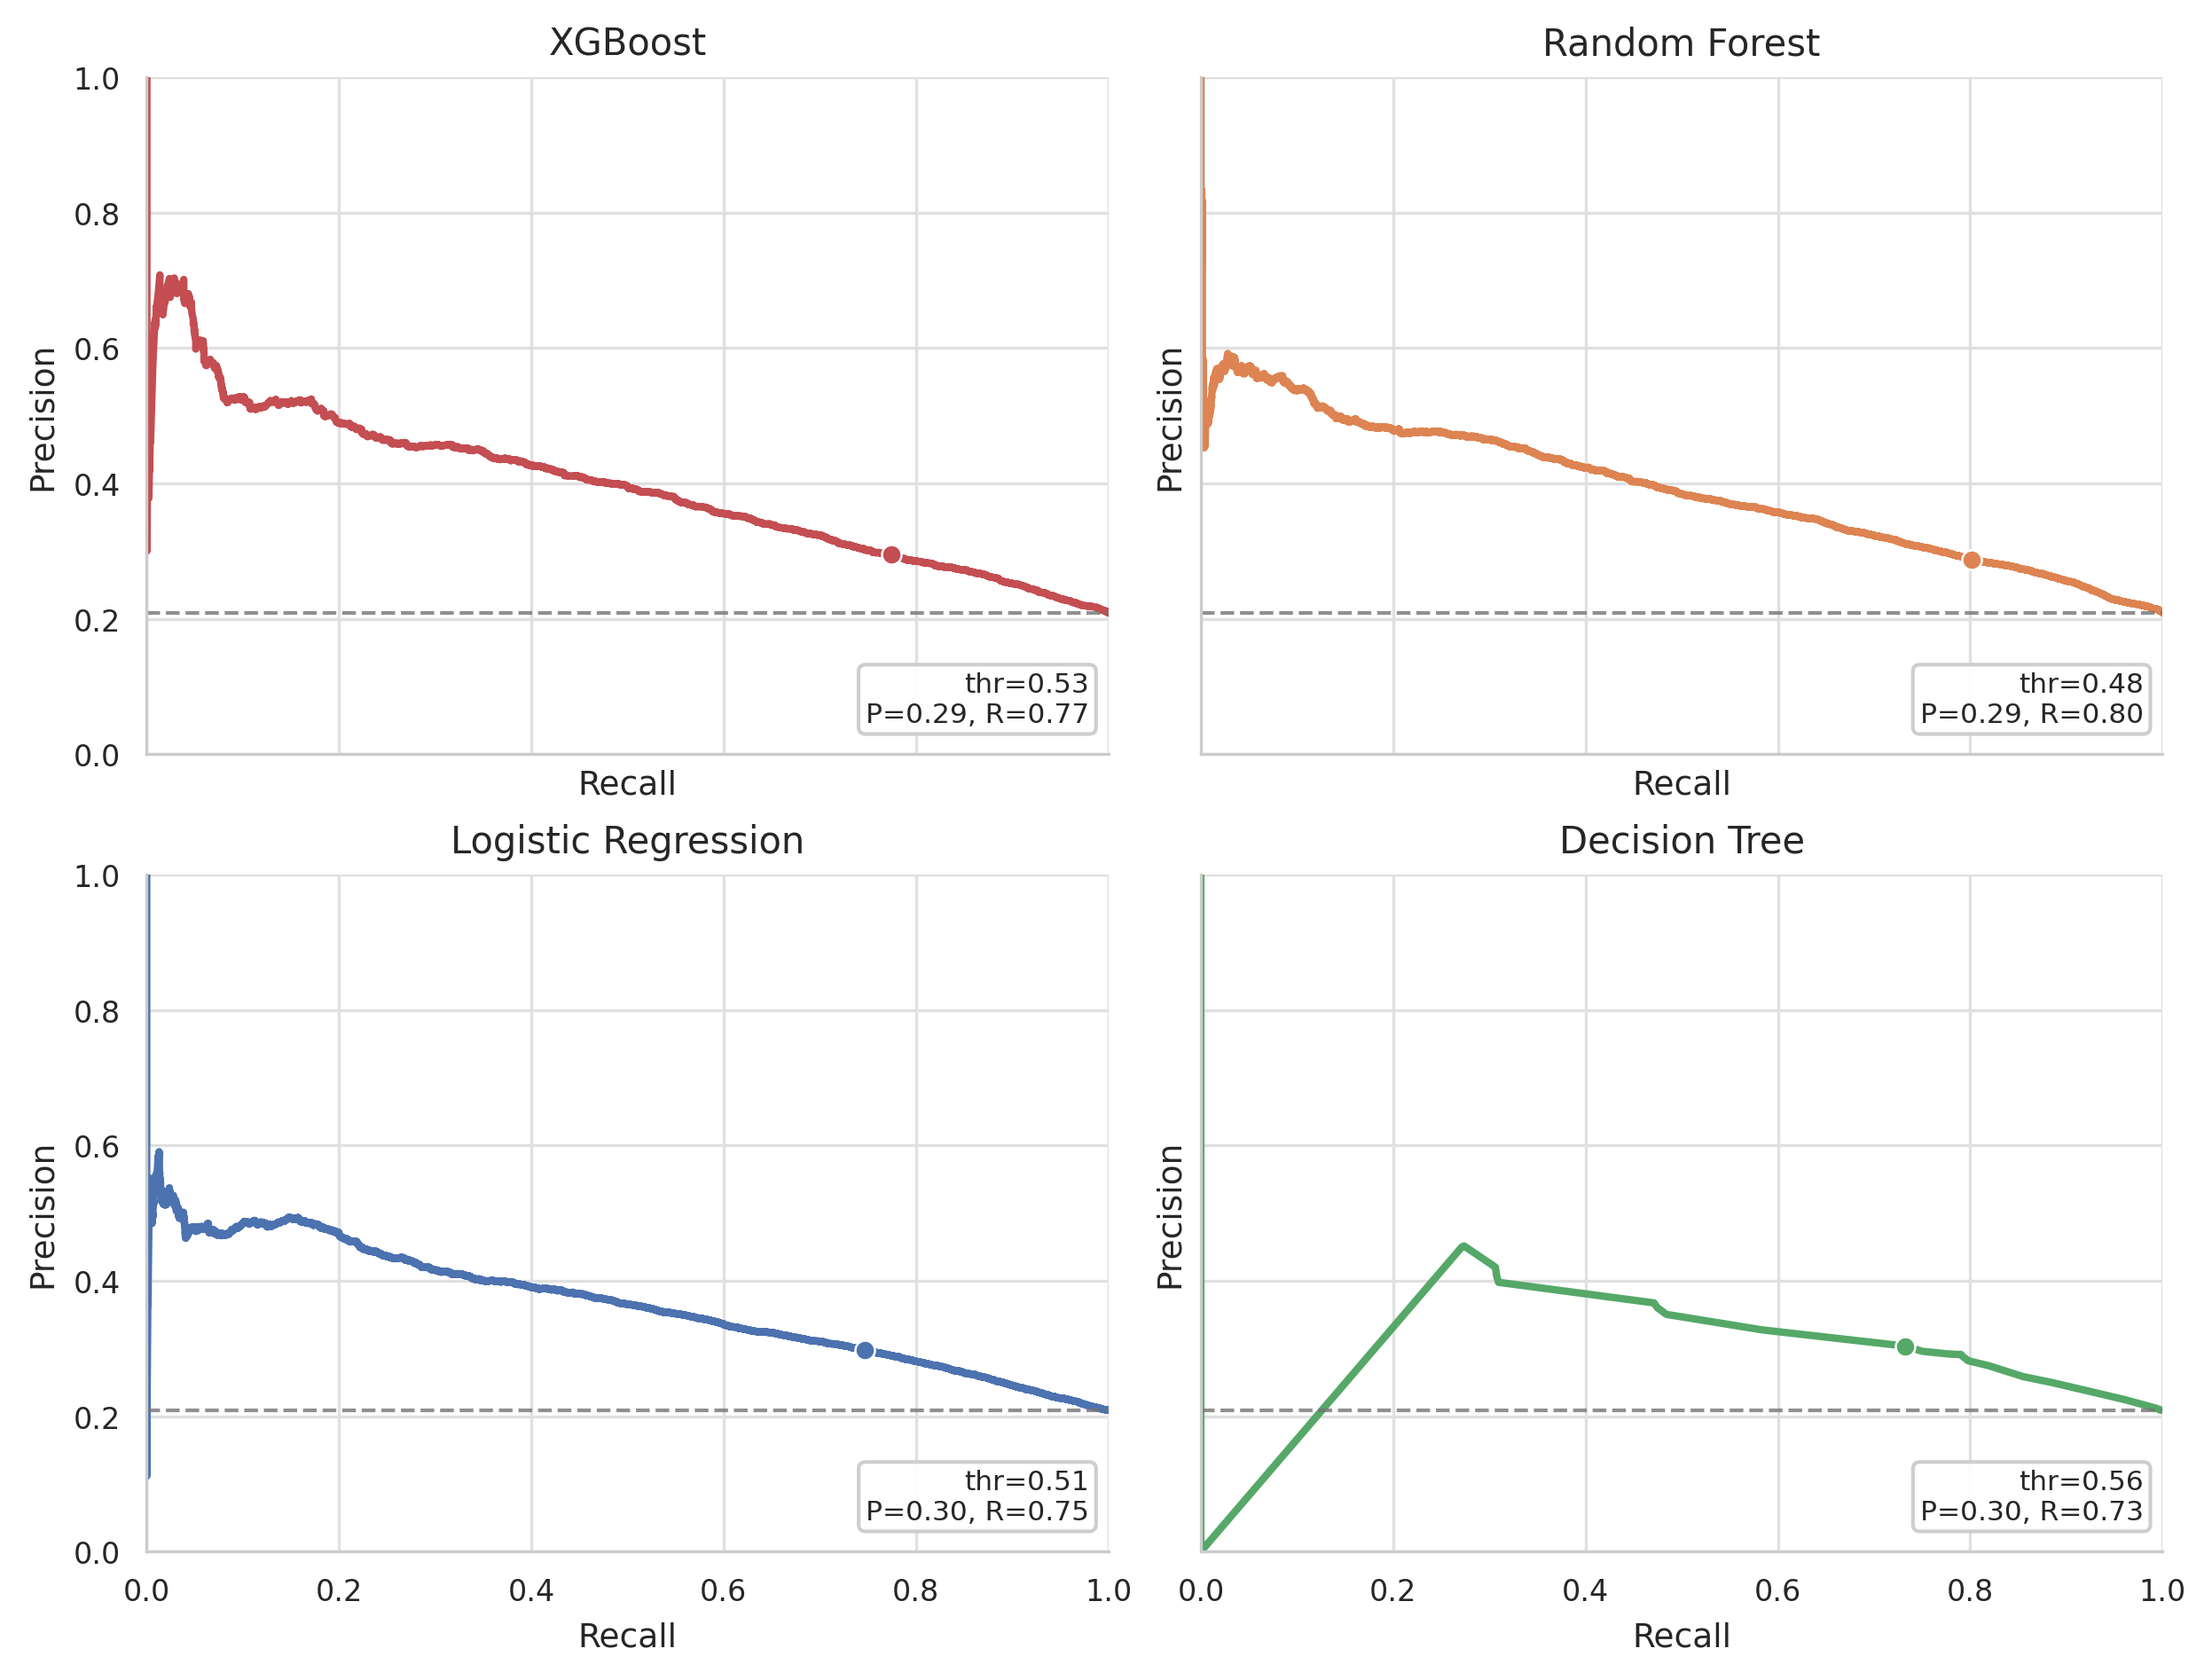

In [80]:
# =============================================================================
# PR Curves — Best configuration per model, Test Set (2022-23)
# 2x2 grid, one panel per model
# =============================================================================

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

positive_base_rate = y_test.mean()

MODEL_COLORS = {
    "LogisticRegression": "#4C72B0",  # muted blue
    "DecisionTree":       "#55A868",  # muted green
    "RandomForest":       "#DD8452",  # muted orange
    "XGBoost":            "#C44E52",  # muted red
}

DISPLAY_NAMES = {
    "LogisticRegression": "Logistic Regression",
    "DecisionTree":       "Decision Tree",
    "RandomForest":       "Random Forest",
    "XGBoost":            "XGBoost",
}

CONFIG = {
    "LogisticRegression": "Baseline SMOTE",
    "DecisionTree":       "Tuned class_weight",
    "RandomForest":       "Tuned class_weight",
    "XGBoost":            "Tuned class_weight",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.2), sharex=True, sharey=True, constrained_layout=True)
axes = axes.flatten()

for ax, row in zip(axes, results_df.itertuples(index=False)):
    name = row.model
    y_proba = test_probas[name]
    best_thr = row.best_threshold
    color = MODEL_COLORS[name]

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    # Operating point corresponding to the chosen threshold
    thr_idx = int(np.argmin(np.abs(thresholds - best_thr)))
    op_precision = precision[thr_idx + 1]
    op_recall = recall[thr_idx + 1]

    ax.plot(recall, precision, color=color, linewidth=2.0, label="PR curve")
    ax.axhline(
        positive_base_rate,
        color="0.45",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        label=f"Base rate = {positive_base_rate:.2f}",
    )
    ax.scatter(
        [op_recall],
        [op_precision],
        s=28,
        color=color,
        edgecolor="white",
        linewidth=0.6,
        zorder=5,
    )

    # ax.set_title(f"{DISPLAY_NAMES[name]}\n[{CONFIG[name]}]", pad=6)
    ax.set_title(f"{DISPLAY_NAMES[name]}", pad=6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, color="0.88", linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.98, 0.04,
        f"thr={best_thr:.2f}\nP={op_precision:.2f}, R={op_recall:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.95),
    )

# fig.suptitle("Precision-Recall Curves (Test Set, 2022–23)", fontsize=11)

plt.savefig(
    "../docs/reports/images/pr_curves_test.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

## Test set evaluation — summary

All four tuned models were scored once on the held-out 2022–23 season.

### Results

| Model               | Val PR-AUC | Test PR-AUC | Δ        | Test F1 | Test Precision | Test Recall |
|---------------------|-----------:|------------:|---------:|--------:|---------------:|------------:|
| XGBoost             | 0.349      | 0.396       | +0.047   | 0.427   | 0.295          | 0.774       |
| Random Forest       | 0.338      | 0.391       | +0.052   | 0.423   | 0.287          | 0.802       |
| Logistic Regression | 0.360      | 0.366       | +0.005   | 0.426   | 0.298          | 0.747       |
| Decision Tree       | 0.332      | 0.347       | +0.014   | 0.429   | 0.303          | 0.733       |

### Key findings

- **Ensembles outperform interpretable models on the test set.**  
  XGBoost beat Logistic Regression by 0.030 PR-AUC (≈8% relative improvement), and Random Forest beat LR by 0.025. This confirms the original project hypothesis ("ensemble models will outperform interpretable models on raw metrics") under the test distribution, even though it did not hold on validation. There's also the fact that rank ordering is affected differently between these models.

- **The val→test gap is highly model-dependent.**  
  LR’s score barely moved (+0.005), while both ensembles jumped by ~0.05 PR-AUC. Two unrelated ensemble methods improving by similar margins suggests 2021–22 was an unusually difficult validation season, likely due to the COVID-aftermath injury spike (23.3% positive rate).

- **Performance ceiling around 0.40 PR-AUC.**  
  Even the best model (XGBoost, 0.396) improves substantially over the 20.9% base rate but falls short of the 0.84 AUC reported by Lu et al. (2022). The gap likely reflects feature differences (biomechanical + positional data vs. workload proxies).

- **Models converge to similar operating points.**  
  F1 ≈ 0.42–0.43, recall ≈ 73–80%, precision ≈ 29–30%. This implies ~3/4 of injuries are caught, at the cost of ~70% false positives — reasonable for screening, less so for automated intervention.


### A note on interpretability

Interpretability here means the model's decision logic is transparent by design: you can inspect it directly. Logistic regression is interpretable in this sense: its signed coefficients indicate what the model weights and in which direction. This is not the same as causal understanding. Correlated features (e.g., rolling load windows) can produce unreliable individual coefficients even when the model predicts well. XGBoost and Random Forest are not interpretable by design; post-hoc methods like SHAP approximate explanations but do not reveal the model's true logic.


### Choice for deployment

Note: XGBoost and Random Forest improved substantially from validation to test (+0.047 and +0.052), while Logistic Regression remained stable (+0.005). This warrants caution: the gap may reflect the validation window's unusually high injury rate (23.3%) rather than a stable performance difference.

This is now a tradeoff:

- **Logistic Regression**
  - Test PR-AUC: 0.366  
  - Interpretable by design. Stable across evaluation windows. 
  - Preferred when medical staff need to audit predictions directly.

- **XGBoost**
  - Test PR-AUC: 0.396  
  - ~8% relative gain over LR.
  - Not interpretable by design; SHAP provides post hoc explanations, not true interpretability. 
  - Preferred when discrimination performance is the priority.

- **Random Forest**
  - Highest recall: 0.802  
  - Catches the most injuries at the cost of more false alarms. 
  - Preferred if missing an injury is worse than over-flagging.

### Next steps

- Reliability diagram on the validation set (2021-22) to assess probability calibration under distribution shift. Note that calibration reflects the validation-era injury rate (~23%), not the training-era rate (~18%), so recalibration would be needed before deployment in any future season 
- Error analysis of false negatives: which players and injury contexts are systematically missed. This is the most operationally relevant analysis for medical staff
- SHAP values for local explanations, with the caveat that correlated rolling load features (7d, 14d, 28d) produce unreliable individual characteristics.